In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm
from matplotlib.patches import Ellipse
import scienceplots
import warnings

from astropy.utils.exceptions import AstropyWarning
import astropy.units as u
from astropy import constants
from astropy.table import Table,QTable

from astropy.coordinates import SkyCoord,FK5,ICRS
from astropy.io import fits,ascii
from astropy.wcs import WCS, utils as wcsutils
from astropy.stats import sigma_clipped_stats
import astropy.visualization as vis
from astropy.cosmology import Planck18
from astropy.modeling import models, fitting,polynomial
import astropy.modeling as modeling
from astropy.nddata import StdDevUncertainty, Cutout2D
from astropy.convolution import Gaussian2DKernel,Gaussian1DKernel

from scipy.signal import find_peaks

from photutils.aperture import EllipticalAperture, SkyEllipticalAperture
from photutils.psf import PSFPhotometry,FittableImageModel,IterativePSFPhotometry
from photutils.detection import DAOStarFinder
from photutils.background import LocalBackground, MMMBackground

from specutils import Spectrum1D, SpectralRegion
from specutils.fitting import estimate_line_parameters,fit_lines,find_lines_threshold,fit_generic_continuum
from specutils.manipulation import extract_region
import sep
from photutils.aperture import EllipticalAperture, SkyEllipticalAperture

import os, sys, glob, pdb

from importlib import reload
from spectral_cube import SpectralCube
from reproject import reproject_interp
from regions import Regions
import linetools

def imshow_astro(img, wcsinfo = None, figsize = (10,10), colorbar =True,
               cblabel="", cbfrac = 0.035, norm = None,
               stretch = vis.LinearStretch(), cmap = "hot",
               vrange = (None, None)):
    
    _, med, std = sigma_clipped_stats(img.data)
    
    fig =  plt.figure(figsize = figsize,dpi=300)
    if wcsinfo:
        ax = plt.subplot(projection = wcsinfo)
    else:
        ax = plt.subplot()
    
    vmin, vmax = vrange
    
    if not vmin:
        vmin = med
    if not vmax:
        vmax = med + 10*std
    if not norm:
        norm = vis.ImageNormalize(vmin = vmin, vmax = vmax, stretch = stretch)
    im = ax.imshow(img, norm = norm, cmap = cmap,origin="lower")
    if colorbar:
        cb = plt.colorbar(im, label = cblabel, fraction =cbfrac)
    return fig, ax, im

In [2]:
multiAGNpath="/disk/bifrost/yuanze/multiAGN"

#psname1="IRAS03582"
#psname2="+6012"
#psname1="Mrk"
#psname2="975"


RA=[43.507814008,43.50724857,43.507573386]
DEC=[14.9700775,14.97041556,14.9708075]

#RA=[18.4626852,18.4644180,18.4622649]
#DEC=[13.2716790,13.2750475,13.2723311]

#UGC2369
psname1="UGC"
psname2="2369"
field=psname1+psname2
stab = ascii.read(multiAGNpath+"/sources.list",format="ipac")
#field=psname1+psname2
sentry = stab[stab["Field"]==field]

#redshift=0.0312
redshift=sentry["z_sys"][0]
datapath=os.path.join(multiAGNpath,psname1+psname2)

#RA=["02h54m01.8010s","02h54m01.7748s","02h54m01.7748s"]
#DEC=["+14d58m14.049s","+14d58m36.912s","+14d58m25.912s"]

#IRAS03582+6012
#RA=["04:02:32.4"]
#DEC=["+60:20:40.1"]


#NGC 6240
#psname1="NGC"
#psname2="6240"
#RA=["16h52m58.8708s"]
#DEC=["+02d24m03.333s"]
#redshift=0.02448
#RA=["01:13:51.1"]
#DEC=["+13:16:18.20"]
#redshift=0.05

#SDSSJ0849+1114
#psname1="SDSS"
#psname2="J0849+1114"
#RA=["08:49:05.5"]
#DEC=["+11:14:47.2"]
#redshift=0.078

#Mrk 248
#psname1="Mrk"
#psname2="248"
#RA=["13:15:17.315 "]
#DEC=["+44:24:25.882"]
#redshift=0.035

#2MASXJ1735+2047
#psname1="2MASX"
#psname2="J1735+2047"
#RA=["17:35:33.7"]
#DEC=["+20:47:47.0"]
#redshift=0.024

#datapath=os.path.join(bpath,psname1+psname2)

In [3]:
sentry["RA"],sentry["Dec"],redshift

(<Column name='RA' dtype='float64' unit='unit' length=3>
 43.5078
 43.5072
 43.5076,
 <Column name='Dec' dtype='float64' unit='unit' length=3>
 14.9701
 14.9704
 14.9708,
 0.0322)

## Examining the MUSE data cube for multiple AGNs

In [98]:
instru="MUSE"

if instru=="OSIRIS":
    cubefile = datapath+"/OSIRIS/UGC23695_clean_swapped_fluxcal.fits"
    Cube=SpectralCube.read(cubefile,hdu=1)
    varCube=None
elif instru=="MUSE":
    cubefile = datapath+"/gist/inputData/{}_{}_S_DATACUBE_FINAL.fits".format(psname1,psname2)
    Cube=SpectralCube.read(cubefile,hdu=1)
    varCube=SpectralCube.read(cubefile,hdu=2)
elif instru=="KCWI":
    cubefile_b = datapath+"/gist-KCWI/inputData/{}{}S_icubes_wcs.fits".format(psname1,psname2)
    cubefile_r = datapath+"/gist-KCWI/inputData/{}{}S-red_icubes_wcs.fits".format(psname1,psname2)
    Cube=SpectralCube.read(cubefile_b,hdu=0)
    Cube_r=SpectralCube.read(cubefile_r,hdu=0)
    varCube = SpectralCube.read(datapath+"/gist-KCWI/inputData/{}{}S_vcubes.fits".format(psname1,psname2),hdu=2)
    varCube_r = SpectralCube.read(datapath+"/gist-KCWI/inputData/{}{}S-red_vcubes.fits".format(psname1,psname2),hdu=2)


In [10]:
hdu=fits.open(cubefile)

In [18]:
WCS(hdu[1].header).pixel_scale_matrix*u.deg.to(u.arcsec)

array([[-2.519e-02,  0.000e+00,  0.000e+00],
       [ 0.000e+00,  2.542e-02,  0.000e+00],
       [ 0.000e+00,  0.000e+00,  4.500e-07]])

39.903455513365


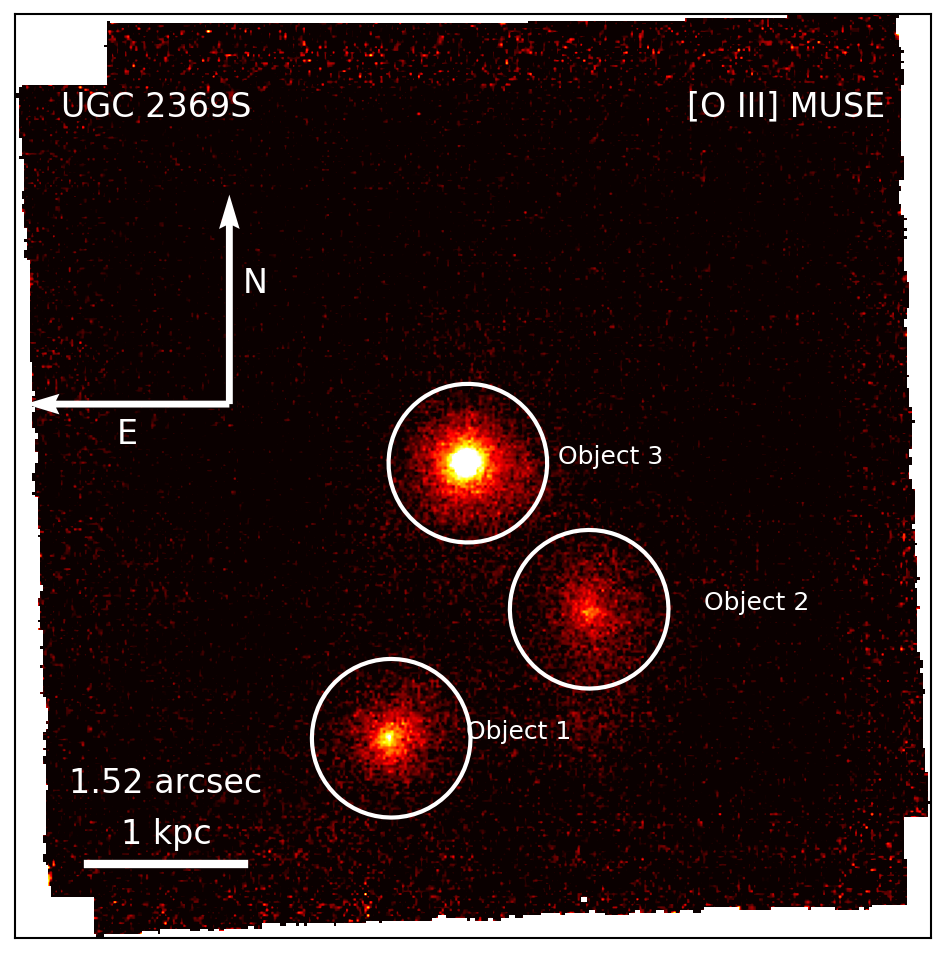

In [140]:
import mpdaf
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":8,
"legend.fancybox":True})
warnings.filterwarnings('ignore', category=AstropyWarning, message='.*WCS1 is missing card CSYER.*')
#redshift=0.0312
if instru=="MUSE":
    brightu=r"Flux $\rm (10^{-20}~erg~s^{-1}~cm^{-2}~\AA^{-1})$"
elif instru=="OSIRIS":
    brightu=r"Flux $\rm (erg~s^{-1}~cm^{-2}~\AA^{-1})$"
wcs=Cube.wcs.celestial


if instru=="OSIRIS":
    rest_wavelength=2.12 * u.micron # [H2]
elif instru=="MUSE":
    rest_wavelength=5008.24 * u.AA## [O III]6564.61* u.AA
    rest_wavelength=mpdaf.obj.vactoair(rest_wavelength.value)* u.AA
elif instru=="KCWI":
    rest_wavelength=5008.24 * u.AA#6564.61* u.AA# [O III]   
pixscale=np.abs(wcs.pixel_scale_matrix[0,0])
desired_wavelength = rest_wavelength * (redshift+1)

testslice = Cube.spectral_slab(desired_wavelength-2*u.AA,desired_wavelength+2*u.AA)
# Find the channel index closest to the desired wavelength:
#channel_index = (np.abs(Cube.spectral_axis - desired_wavelength)).argmin()
# Spatial slice


ts=testslice.sum(axis=0)
slicev=ts.value

_, med, std = sigma_clipped_stats(slicev)
fig, ax, im = imshow_astro(slicev, cblabel = brightu,colorbar=False,figsize=(8,4), vrange = (std, med+10*std))

#fig,ax=plt.subplots(1,dpi=300)
#ax.imshow(slicev)
#===========================================
if instru=="OSIRIS":
    x0,y0 = 0.2, 0.7
    arrow_length = -0.1
    fcolor="m"
    sfac=0.0
elif instru=="MUSE":
    x0, y0 = 80,200
    arrow_length = 2/3600
    fcolor="white"
    sfac=0.0
elif instru=="KCWI":
    x0, y0 = 15,40
    arrow_length = 2/3600
    fcolor="white"
    sfac=0.0




# Convert pixel coordinates to sky coordinates (RA, Dec)
sky_coords = wcs.pixel_to_world(x0, y0)
ra, dec = sky_coords.ra.deg, sky_coords.dec.deg

# Define the end points of the arrows in pixel coordinates
north_end = wcs.world_to_pixel_values(ra, dec + arrow_length)
east_end = wcs.world_to_pixel_values(ra + arrow_length, dec)


# Calculate the direction vectors for the arrows
north_vector = [north_end[0] - x0, north_end[1] - y0]
east_vector = [east_end[0] - x0, east_end[1] - y0]

# Plot the North arrow
ax.quiver(x0, y0, north_vector[0], north_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
ax.text(x0 + north_vector[0]/2+5, y0 + north_vector[1]/2, 'N', color='w', ha='left', va='bottom')

# Plot the East arrow
ax.quiver(x0, y0, east_vector[0], east_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
ax.text(x0 + east_vector[0]/2, y0 + east_vector[1]/2-5, 'E', color='w', ha='center', va='top')

#===========================================

dT = 1  # kpc distance
delta_theta_deg = dT/Planck18.kpc_proper_per_arcmin(0.0318).value/60
print(Planck18.kpc_proper_per_arcmin(redshift).value)
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()
start_x = x_lim[0] + 0.08 * (x_lim[1] - x_lim[0])
start_y = y_lim[0] + 0.08 * (y_lim[1] - y_lim[0])
start_coord = wcs.pixel_to_world(start_x, start_y)
end_coord = wcs.pixel_to_world(start_x + 1, start_y)  # arbitrary +1 in pixel to get RA difference for 1 pixel

delta_ra_per_pixel = start_coord.ra.degree - end_coord.ra.degree
length_in_pixels = delta_theta_deg / np.abs(delta_ra_per_pixel)
delta_arcsec=delta_theta_deg*3600#length_in_pixels*pixscale*3600
#length_in_pixels2 = delta_theta_deg2 / delta_ra_per_pixel

#ax.plot([start_x, start_x + length_in_pixels2], [start_y-1, start_y-1], color='white', lw=2)

ax.plot([start_x, start_x + length_in_pixels], [start_y, start_y], color=fcolor, lw=2)
ax.text(start_x + length_in_pixels / 2, start_y*1.2, '{} kpc'.format(dT), color=fcolor, ha='center', va='bottom')
ax.text(start_x + length_in_pixels / 2, start_y*1.9, '{:.2f} arcsec'.format(delta_arcsec), color=fcolor, ha='center', va='bottom')

#for io in range(len(RA)):
#    ax.plot(RA[io], DEC[io],"+", transform=ax.get_transform('world'),c="g",ms=30,lw=0.1)
#    ax.text(RA[io], DEC[io],"Obj. {}".format(io+1),color="g",transform=ax.get_transform('world'),verticalalignment='bottom',horizontalalignment='right',fontsize=15)

for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=2*rfix[i],
                height=2*rfix[i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('w')
    ax.add_artist(e)
    ax.text(objects['x'][i]*1.2,objects['y'][i],"Object {:d}".format(objid[i]),color="w",fontsize=6)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.text(0.05,0.89,"{} {}S".format(psname1,psname2),color="white",transform=ax.transAxes)
ax.text(0.95,0.89,"{} {}".format(r"[O III]",instru),color="white",transform=ax.transAxes,horizontalalignment="right")
#ax.text(0.95,0.89,"{} {}".format(r"H$\alpha$",instru),color="white",transform=ax.transAxes,horizontalalignment="right")

#if instru=="OSIRIS":
#    ax.invert_yaxis()
#ax.add_artist(mask_reg.bbox.as_artist(facecolor='none', edgecolor='white'))
#ax.add_artist(region_pix.as_artist(facecolor='none', edgecolor='green'))
#ax.set_title(r"{} slice at {}(z={})".format(instru,rest_wavelength,round(redshift,2)))
#fig.savefig(datapath+"/fig/{}S_{}_Ha.pdf".format(psname1+psname2,instru))
fig.savefig(datapath+"/fig/{}S_{}_OIII.pdf".format(psname1+psname2,instru))

In [758]:
north_end

(array(79.99921724), array(260.00000027))

## Source detection with [O III] 5009

In [107]:
bkg=sep.Background(slicev)

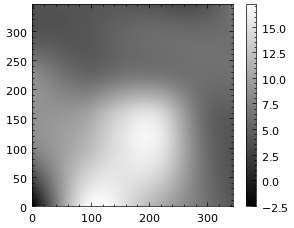

In [113]:
bkg_image = bkg.back()
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [118]:
data_sub = slicev - bkg
objects = sep.extract(data_sub, 2.0,minarea=15, err=bkg.globalrms)

In [119]:
pixscale*3600

0.025189999999999994

In [120]:
rmax=1./3600/pixscale
ar=0.75
rfix=np.ones(objects['y'].shape)*ar/3600/pixscale
kronrad, krflag = sep.kron_radius(data_sub, objects['x'], objects['y'], objects['a'], objects['b'], objects['theta'], 6)
frad,fflag = sep.flux_radius(data_sub, objects['x'], objects['y'],np.ones(objects['y'].shape)*rmax,0.9)

In [121]:
frad*pixscale*3600

array([0.73477533, 0.88426354, 0.78763269])

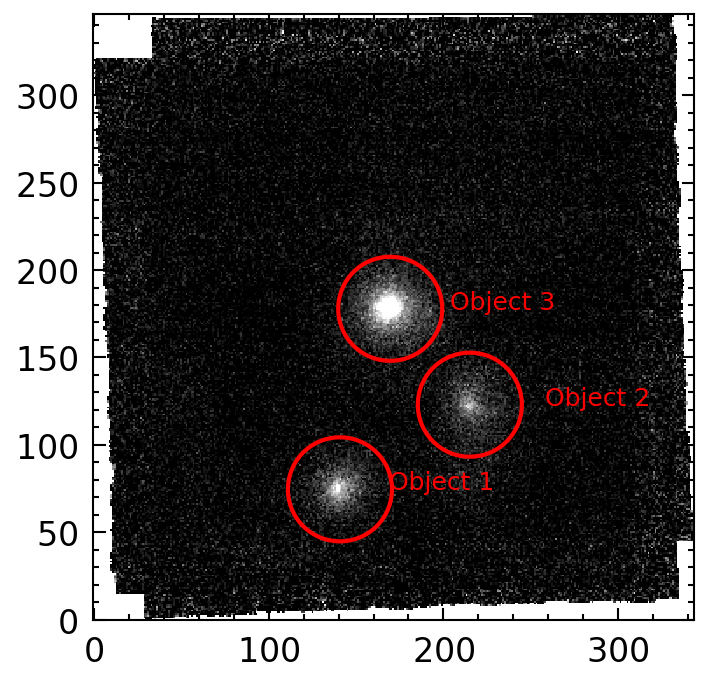

In [122]:

# plot background-subtracted image
fig, ax = plt.subplots(dpi=300)
_, m, s = sigma_clipped_stats(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m, vmax=m+8*s, origin='lower')
# plot an ellipse for each object
if instru=="OSIRIS":
    objid=[3,1]
elif instru=="MUSE":
    objid=np.arange(len(objects))+1
elif instru=="KCWI":
    objid=[2,3,1]
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=2*rfix[i],
                height=2*rfix[i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)
    ax.text(objects['x'][i]*1.2,objects['y'][i],"Object {:d}".format(objid[i]),color="red",fontsize=6)

In [152]:
dis=[pixscale*3600*np.sqrt((objects['x'][i]-objects['x'][i+1])**2+(objects['y'][i]-objects['y'][i+1])**2) for i in range(2)]
dis.append(pixscale*3600*np.sqrt((objects['x'][0]-objects['x'][2])**2+(objects['y'][0]-objects['y'][2])**2))

In [153]:
type(objects)

numpy.ndarray

In [154]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     rfix, err=bkg.globalrms, gain=1.0)

In [155]:
SkyCoord("332.217 -19.733",unit=u.deg).to_string("hmsdms")

'22h08m52.08s -19d43m58.8s'

In [156]:
for i in range(len(objects)):
    print("object {:d}: flux = {:e} +/- {:e}".format(objid[i], flux[i], fluxerr[i]))

object 2: flux = 1.333820e+03 +/- 3.670254e+01
object 3: flux = 2.360867e+03 +/- 4.872551e+01
object 1: flux = 1.427079e+03 +/- 3.795218e+01


In [157]:
museps=Cube.wcs.celestial.pixel_scale_matrix[1,1] * 3600
obj=objects[1]
area=np.pi*3*obj['b']*3*obj['a']*museps**2
print("pixel scale:",Cube.wcs.celestial.pixel_scale_matrix*3600)
print("Area (arcsec^2):",area)

pixel scale: [[-0.146  0.   ]
 [ 0.     0.146]]
Area (arcsec^2): 43.04531302868553


## Spectrum extraction with detected source

In [158]:
from regions.core import PixCoord
from astropy.coordinates import Angle
from regions.shapes.circle import CircleSkyRegion,CirclePixelRegion
from regions.shapes import CircleAnnulusSkyRegion,EllipseSkyRegion,EllipsePixelRegion

In [159]:
sources=[]
for ind,obj in enumerate(objects):
    sources.append(EllipsePixelRegion(PixCoord(obj['x'], obj['y']), width=2.*rfix[ind], height=2.*rfix[ind],
                         angle=Angle(obj['theta']/np.pi*180, 'deg')))

In [160]:
print("saving nuclear spectrum of {}".format(instru))
obj_spec=[]
obj_err=[]
warnings.filterwarnings('ignore', category=AstropyWarning, message='.*WCS1 is missing card CSYER.*')
for ind,reg in enumerate(sources):
    #reg_pix=reg.to_pixel(wcsinfo)
    try:
        if instru == "KCWI":
            obj_cube_b=Cube.subcube_from_regions([reg])
            obj_cube_r=Cube_r.subcube_from_regions([reg])
            spec=np.append(obj_cube_b.sum(axis=(1,2),how="slice"),obj_cube_r.sum(axis=(1,2),how="slice")).value*(pixscale*3600)**2
            obj_var_b=varCube.subcube_from_regions([reg])
            obj_var_r=varCube_r.subcube_from_regions([reg])
            sigma=np.sqrt(np.append(obj_var_b.sum(axis=(1,2),how="slice"),obj_var_r.sum(axis=(1,2),how="slice"))).value*(pixscale*3600)**2
        else:
            obj_cube=Cube.subcube_from_regions([reg])
            spec=obj_cube.sum(axis=(1,2),how="slice")
    except:
        print("Region extraction failed for:",reg)
        continue
    if instru == "MUSE":
        obj_var=varCube.subcube_from_regions([reg])
        sigma=np.sqrt(obj_var.sum(axis=(1,2),how="slice"))
    elif instru=="OSIRIS":
        sigma=0.1*spec ## assuming 10% uncertainty at this time
    
    
    mask=spec<0 #| np.isnan(spec)  masking undesirable spectral region
    
    obj_spec.append(spec[~mask])
    #npix=np.sum((~np.isnan(obj_var)).astype(int))
    
    #obj_err.append(sigma[~mask])
    data_to_save=np.array([np.append(Cube.spectral_axis,Cube_r.spectral_axis)[~mask],spec[~mask],sigma[~mask]]).T
    print("saving nuclear spectrum for Object",objid[ind])
    if instru=="MUSE":
        np.savetxt(datapath+"/MUSE_1D/MUSE_nuclear_spec_r{}_obj{}.txt".format(ar,objid[ind]),data_to_save)
    elif instru=="OSIRIS":
        np.savetxt(datapath+"/OSIRIS_1D/OSIRIS_nuclear_spec_obj{}.txt".format(objid[ind]),data_to_save)
    elif instru=="KCWI":
        np.savetxt(datapath+"/KCWI_1D/KCWI_nuclear_spec_obj{}.txt".format(objid[ind]),data_to_save)

saving nuclear spectrum of KCWI
saving nuclear spectrum for Object 2
saving nuclear spectrum for Object 3
saving nuclear spectrum for Object 1


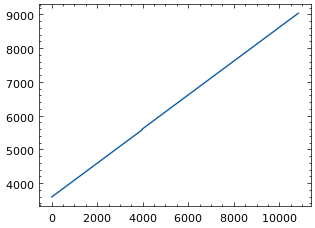

In [131]:
plt.plot(np.append(Cube.spectral_axis,Cube_r.spectral_axis)[~mask])

In [133]:
Cube.spectral_axis.min()

<Quantity 3592.5 Angstrom>

In [163]:
lines={'[N II]':[6548.,6583.],"[S II]":[6716.,6731.] ,'[O III]':[4959,5007],'[O II]':[3727], r"H$\alpha$":[6563], r"H$\beta$":[4861.],"CaII":[8498, 8542, 8662]}#,"Fe II":[6491.28,6385.45,6598.3]}

In [646]:
from specutils.fitting import fit_generic_continuum

fitter = fitting.LevMarLSQFitter()
#g_init = models.Const1D(amplitude=10000)

blines=[6563,4861,5008]
nlines=[6548,6583,6716,6731]
skip_broad=[False,True,False]
#vshift=[0,100,200]
zarray=[0.032,0.0317,0.0317]
ncomp=2
stds=[10,1.5]
fixa=[False,True]
amps=[5e4*Cube.unit,2e4*Cube.unit]
csr=SpectralRegion(4990*u.AA,5030*u.AA)+SpectralRegion(4950*u.AA,4970*u.AA)+SpectralRegion(4840*u.AA,4880*u.AA)+SpectralRegion(6520*u.AA,6640*u.AA)+SpectralRegion(6700*u.AA,6750*u.AA)
ssr=[SpectralRegion(4500*u.AA,5500*u.AA),SpectralRegion(6300*u.AA,7000*u.AA)]

        #g_init += models.Voigt1D(amplitude_L=2e4*Cube.unit, x_0=wav*u.AA,fwhm_L=1.*u.AA,fwhm_G=1.5*u.AA)
#hcut=1650
#lcut=1550
#hcut=-1
#lcut=0
g_fit={}
continuum={}
#zcgm=0.032
for ss, spec in enumerate(obj_spec):
    
    # spectrum reading
    mask=mask0 | np.isnan(spec) |(~np.isfinite(1.0/obj_err[ss]))
    spectrum=Spectrum1D(flux=spec[~mask],spectral_axis=x[~mask]*(1+redshift)/(1+zarray[ss]),uncertainty=StdDevUncertainty(obj_err[ss][~mask]))
    for j, sregion in enumerate(ssr):
        # selecting continuum modeling region
        sub_spectrum = extract_region(spectrum, sregion)        
        cont_fit=fit_generic_continuum(sub_spectrum,exclude_regions=csr)#modeling.powerlaws.BrokenPowerLaw1D())
        y_continuum_fitted=cont_fit(sub_spectrum.spectral_axis)

        # defining models
        # initialize model parameter
        set=True
        g_init = models.Const1D(amplitude=1)
        # broad line setup
        for i,wav in enumerate(blines):
            #print(wav)
            if (wav*u.AA>sub_spectrum.spectral_axis[-1]) | (wav*u.AA<sub_spectrum.spectral_axis[0]):
                #print("skipping",wav,"for",sregion)
                continue
            if not set:
                g_init = models.Gaussian1D(amplitude=amps[0], mean=wav*u.AA, stddev=stds[0]*u.AA)
                g_init.stddev.fixed=fixa[0]
                #print(g_init)
                set=True
                for comp in range(ncomp-1):
                    if skip_broad[ss]:
                        break
                    g_init += models.Gaussian1D(amplitude=amps[1], mean=wav*u.AA, stddev=stds[comp+1]*u.AA)
                    g_init[-1].stddev.fixed=fixa[comp+1]
            else:
                for comp in range(ncomp):
                    if skip_broad[ss] and comp>0:
                        break
                    g_init += models.Gaussian1D(amplitude=amps[comp], mean=wav*u.AA, stddev=stds[comp]*u.AA)
                    g_init[-1].stddev.fixed=fixa[comp]
        #print("after broad line setup:",g_init)
        # narrow line setup
        if len(nlines)>0:
            for i,wav in enumerate(nlines):
                if (wav*u.AA>sub_spectrum.spectral_axis[-1]) | (wav*u.AA<sub_spectrum.spectral_axis[0]):
                    continue
                g_init += models.Gaussian1D(amplitude=2e4*Cube.unit, mean=wav*u.AA, stddev=1.5*u.AA)
                g_init[-1].stddev.fixed = True

        
        
        
        if j==0:
            continuum["Object_%d"%(ss+1)]=[cont_fit]
            g_fit["Object_%d"%(ss+1)]=[fit_lines(sub_spectrum-y_continuum_fitted,g_init,weights='unc')]
        else:
            continuum["Object_%d"%(ss+1)].append(cont_fit)
            g_fit["Object_%d"%(ss+1)].append(fit_lines(sub_spectrum-y_continuum_fitted,g_init,weights='unc'))
        


In [642]:
fr=g_fit["Object_3"][1]
FWHM= constants.c.to(u.km/u.s).value*(2 * np.sqrt(2 * np.log(2)) * fr.stddev_1.value)/fr.mean_1.value
print(FWHM)

1668.0773258368956


In [726]:
time=10*u.kpc/(0.1*constants.c)
print(time.to(u.year))

326156.3777167433 yr


### object plot

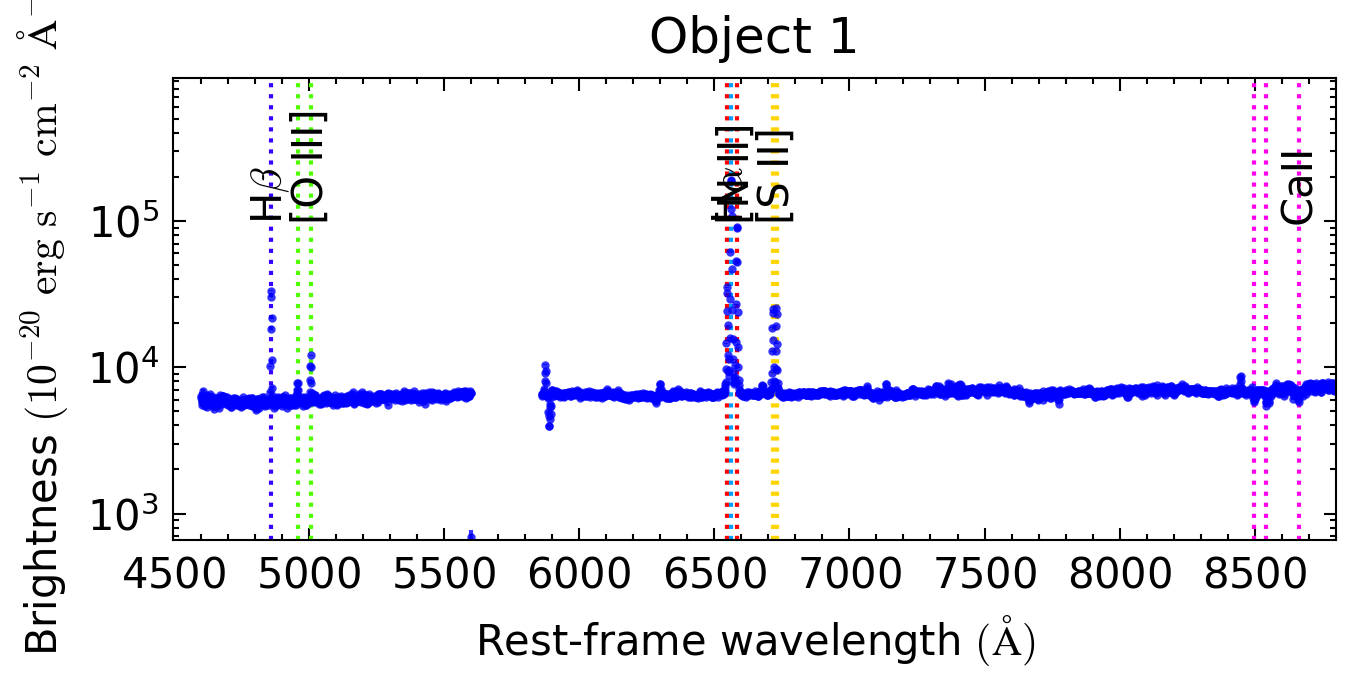

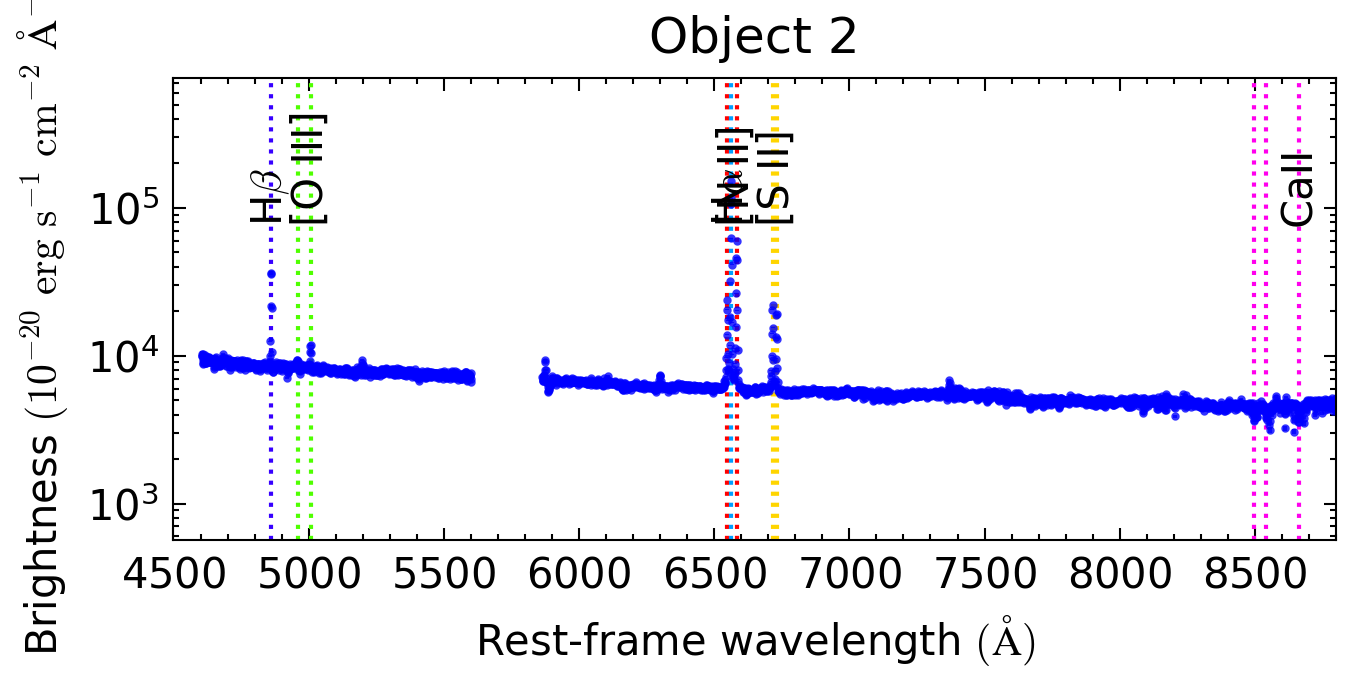

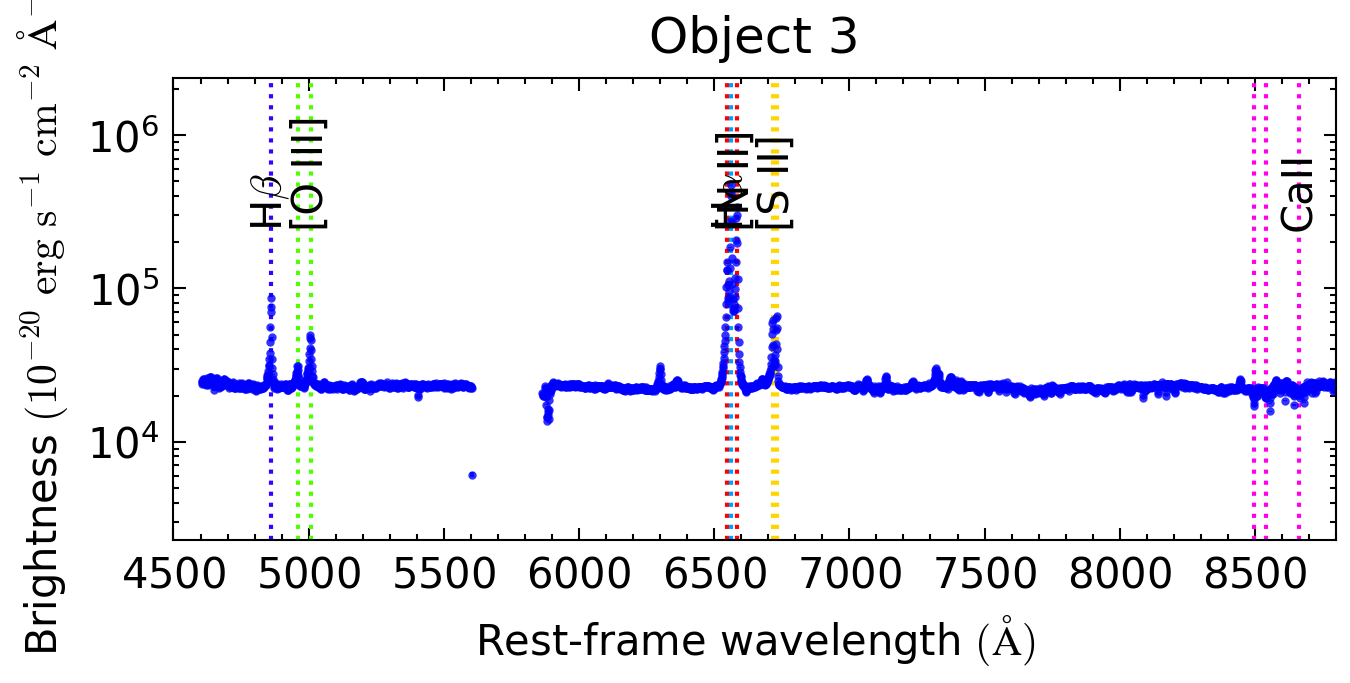

In [176]:
import matplotlib
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":10,
"legend.fancybox":True})
#rng1 = np.random.default_rng(122807528840384100672342137672332424406)
#Yunit = r"F$_{\nu}\,\rm (mJy)$"

keys=lines.keys()
colors=matplotlib.cm.hsv(np.arange(len(keys))/len(keys))

zarray=[0.032,0.0317,0.0316]
# redshift of the CGM being probed. QSO sight-line
#zcgm = 0.0317
zcgm=redshift
rlinec= (zcgm+1)/(redshift+1)

x = Cube.spectral_axis/(1+redshift)
mask0=np.full(len(x),False)
xlow=x[0]
xhigh=x[-1]

for ss,thisspec in enumerate(obj_spec):
    mask=mask0 | np.isnan(thisspec) |(~np.isfinite(1.0/obj_err[ss]))
    spectrum=Spectrum1D(flux=thisspec[~mask],spectral_axis=x[~mask]*(1+redshift)/(1+zarray[ss]),uncertainty=StdDevUncertainty(obj_err[ss][~mask]))
    fig, ax = plt.subplots(figsize=(5,2),dpi=300)
    
    ylow=spectrum.median().value
    #ylow=g_fit[ss].amplitude_0.value
    yup=spectrum.max().value
    #Marking the important lines
    #ax.axvline(rlinec*1215.67,ls=":")
    #ax.text(rlinec*1215.67, 0.8*yup,r"Ly$\alpha$", rotation=90,verticalalignment='bottom',horizontalalignment='center')
    xlow=4500
    xhigh=8800
    ax.set_ylim(0.1*ylow, yup*5)
    ax.set_xlim([xlow,xhigh])
    
    
    for ind,key in enumerate(keys):
        for line in lines[key]:
            if line < xhigh and line > xlow:
                ax.axvline(rlinec*line,ls=":",c=colors[ind])
    #            masktmp = (x.value < ((1+redshift)*line*(1+dlam))) & (x.value > ((1+redshift)*line*(1-dlam)))
    #            mask= mask | masktmp
               # print(x[mask])
        if line < xhigh and line > xlow:
            ax.text(rlinec*line, 5e-1*yup,key, rotation=90,verticalalignment='bottom',horizontalalignment='center')
    #        ax.text(rlinec*line, 5e-1+10**(-4*rng1.random()),key,verticalalignment='bottom',horizontalalignment='center',fontsize=10)

    """
    all_m=g_fit["Object_%d"%(ss+1)]
    all_cont=continuum["Object_%d"%(ss+1)]
    for nr,sregion in enumerate(ssr):
        subspec=extract_region(spectrum, sregion)
        cont=all_cont[nr](subspec.spectral_axis)
        for comp in range(all_m[nr].n_submodels):
                yfit=all_m[nr][comp](subspec.spectral_axis)
                ax.plot(subspec.spectral_axis,yfit)
        yfit=all_m[nr](subspec.spectral_axis)
        ax.plot(subspec.spectral_axis,yfit+cont,"m",label="Full Model")
        #yfit=continuum[ss](x*u.AA/(1+redshift))
    #
    """
    #ax.plot(x[~mask]/(1+redshift), spec[~mask],"b",alpha=0.9, label = "Average Brightness")
    ax.errorbar(spectrum.spectral_axis, thisspec[~mask],yerr=obj_err[ss][~mask],fmt="ob",mfc="none",ms=1,alpha=0.8)
    #ax.fill_between(x.value/(1+redshift), spec.value - sigma, spec.value + sigma, color='cyan', alpha=0.2, label='1-sigma region')
    
    #sfeii=5e-4
    #ax.plot(rlinec*wavemodel,fluxmodel*sfeii,color="m",label="Fe II")
    #ax.plot(rlinec*wavemodel,fluxmodel*sfeii,color="m",label="Fe II")
    
    #ax.legend()
    ax.set_xlabel(r"Rest-frame wavelength $(\rm \AA)$")
    ax.set_ylabel(brightu)
    ax.set_yscale("log")
    ax.set_title("Object {:d}".format(ss+1))
   # fig.savefig(bpath+"/MUSE_nuclear_{}_{}_{}.pdf".format(xlow,xhigh,ss+1))




In [658]:
selectline={"[N II]":[6583],"[O III]":[5008],r"H$\beta$":[4861],r"H$\alpha$":[6563]}
Fline={}
for ss,obj in enumerate(g_fit.keys()):
    line_dict={}
    for line in selectline.keys():
        for sr,sregion in enumerate(ssr):
            for i in range(g_fit[obj][sr].n_submodels):
                if i == 0:
                    continue
                component = g_fit[obj][sr][i]
                if np.abs(component.mean.value - selectline[line][0])<5:                    
                    if line in line_dict.keys():
                        print("adding extra component of ",line," with line center at",component.mean.value)
                        line_dict[line]+=component.amplitude.value*component.stddev.value*np.sqrt(2 * np.pi)
                    else:
                        line_dict[line]=component.amplitude.value*component.stddev.value*np.sqrt(2 * np.pi)
    Fline[obj]=line_dict

adding extra component of  [O III]  with line center at 5006.875347397944
adding extra component of  H$\beta$  with line center at 4861.171420107765
adding extra component of  H$\alpha$  with line center at 6562.632907815131
adding extra component of  [O III]  with line center at 5005.928249920578
adding extra component of  H$\beta$  with line center at 4860.486926980764
adding extra component of  H$\alpha$  with line center at 6561.742708313064


In [742]:
Fline['Object_2']['[O III]']*1e-20/area

4.861860916546722e-16

In [1]:
f      = plt.figure(dpi=300)
ax                 = f.add_subplot(1,1,1)
bins_X, bins_Y     =  60., 60.   # Define the number of bins in X- and Y- axis
Xmin, Xmax         = -1.2, 1.2   # Define the maximum and minimum limit in X-axis
Ymin, Ymax         = -1.5, 1.0   # Define the maximum and minimum limit in Y-axis
Nlevels            = 6           # Define the number of levels of isocontour
Nsize = 8
for obj in Fline.keys():
    line_obj=Fline[obj]
    
    xx     = np.log10(  line_obj["[N II]"] / line_obj[r"H$\alpha$"] )      # log10(NII/Halpha)
    yy     = np.log10( line_obj["[O III]"] /  line_obj[r"H$\beta$"] )      # log10(OIII/Hbeta)
    


    ax.errorbar(xx,yy,fmt="*")
    ax.text(xx,yy*1.1,obj,fontsize=Nsize)
    #hist,xedges,yedges = np.histogram2d(xx,yy,bins=(bins_X, bins_Y),range=[[Xmin,Xmax],[Ymin,Ymax]])
    #masked             = np.ma.masked_where(hist==0, hist)
    #plotting           = ax.imshow(masked.T,extent=[Xmin, Xmax, Ymin, Ymax],interpolation='nearest',origin='lower',cmap=plt.cm.gray_r)
    #levels             = np.linspace(0., np.log10(masked.max()), Nlevels)[1:]
    #CS                 = ax.contour(np.log10(masked.T), levels, colors='k',linewidths=1,extent=[Xmin,Xmax,Ymin,Ymax])
    
    
    # Kewley+01 ------------------------------------------
    X = np.linspace(-1.5,0.3)
    Y = (0.61/( X  - 0.47  )) + 1.19
    
    # Schawinski+07 --------------------------------------
    X3 = np.linspace(-0.180,1.5)
    Y3 = 1.05*X3 + 0.45
    
    # Kauffmann+03 ---------------------------------------
    Xk = np.linspace(-1.5,0.)
    Yk = 0.61/(Xk -0.05) + 1.3
    
    # Regions --------------------------------------------
    ax.plot(X,   Y, '-' , color='blue', lw=1, label='Kewley+01'    ) # Kewley+01
    ax.plot(X3, Y3, '-', color='blue', lw=1, label='Schawinski+07') # Schawinski+07
    ax.plot(Xk, Yk, '--', color='blue', lw=1, label='Kauffmann+03' ) # Kauffmann+03
    
    # Axi name here ...
    
    ax.set_xlabel(r'log([NII] $\lambda$ 6583/H$\alpha$)',fontsize=Nsize)
    ax.set_ylabel(r'log([OIII] $\lambda$ 5007/H$\beta$)',fontsize=Nsize)
    ax.tick_params(labelsize = Nsize)
    ax.legend
    ax.set_ylim(Ymin, Ymax)
    ax.set_xlim(Xmin, Xmax)


NameError: name 'plt' is not defined

There are probably nuclear starbursts due to the major merger gas funneling. Simple apearture spectroscopy does not indicate the existence of AGN from BPT diagram. However, Object_3 is almost certainly a broad line object.

## Chandra data analysis
* read in the 0.5-7 keV exposure time corrected image
* Note that the astrometry haven't been corrected (Checked: no significant mis-alignment. Almost perfectly on-axis)

In [4]:
Lx={}
Lxall={}
SFR={}
Lxerr={}

In [5]:
from regions.core import PixCoord
from astropy.coordinates import Angle
from regions.shapes.circle import CircleSkyRegion,CirclePixelRegion
from regions.shapes import CircleAnnulusSkyRegion,CircleAnnulusPixelRegion,EllipseSkyRegion,EllipsePixelRegion

cdata="/disk/bifrost/yuanze/my_work/xray/chandra"
psname=psname1+psname2
#p2e_int=[[2.2699e-05,10**(-12.9864)],[2.006e-5,3.2463e-14],[3.2502e-06,10**(-13.6674)]]
#p2e=[[2.206e-5,4.1171e-14],[2.006e-5,3.2463e-14],[2.0002e-6,8.708e-15]]

p2e=[[6.1414e-06,1.4538e-14],[4.9651e-06,8.0119e-15],[1.1762e-06,8.0191e-15]] ## using object 3 x-ray SED, [photon/s, energy flux (cgs)], 2-10 keV flux is extrapolated using 2-7 keV photon counts.
ldist=Planck18.luminosity_distance(0.0320).to(u.cm).value
root=os.path.join(cdata,psname)
pnlist=["04058","28148","29089"]

npn=1

if npn==0:
    pnumber="4058"
else:
    pnumber=pnlist[npn]


cpspath=os.path.join(root,"stack_img/merged_obs/")
psfpath=os.path.join(root,f"psf/{pnlist[npn]}")
erange=["broad","0.5-2.0","hard"]

psf=fits.open(psfpath+f"/{pnlist[npn]}.psf")
psf_model = FittableImageModel(psf[0].data)
psf_model_all=psf_model+psf_model+psf_model
#psf_model_all.x_0_0=True

#chdu=fits.open(cpspath+f"/{erange[1]}_flux.img")

In [61]:
np.sqrt(x_offset2**2+y_offset2**2)*pix_scale

NameError: name 'x_offset2' is not defined

In [62]:
r12=np.sqrt((init_params['x'][0]-init_params['x'][1])**2+(init_params['y'][0]-init_params['y'][1])**2)*pix_scale
r13=np.sqrt((init_params['x'][2]-init_params['x'][0])**2+(init_params['y'][2]-init_params['y'][0])**2)*pix_scale
r23=np.sqrt((init_params['x'][2]-init_params['x'][1])**2+(init_params['y'][2]-init_params['y'][1])**2)*pix_scale

NameError: name 'init_params' is not defined

2.758021490446368

#### PSF photometry

'\nax.legend(labelcolor="white")\n\nax.set_xlabel("R.A.")\nax.set_ylabel("Dec.")\n#if re.findall(r"606W.+",dataname):\n    #ax.invert_xaxis()\n#ax.set_title("UGC 2369s")\n#pixsc=wcs.world_to_pixel(sc)\n#ax.plot(pixsc[0],pixsc[1],"ro",markeredgewidth=.1,lw=0.01)\n#plt.scatter(pixsc[0],pixsc[1], s=55, facecolors=\'none\', edgecolors=\'r\')\n#ax.plot(43.507395, 14.976920,"+", transform=ax.get_transform(\'world\'),c="g",ms=30,lw=0.1)\n\nfor io in range(len(RA)):\n    ax.plot(RA[io], DEC[io],"+", transform=ax.get_transform(\'world\'),c="g",ms=5,lw=0.1)\n    #ax.text(RA[io], DEC[io],"UGC 2369",color="g",transform=ax.get_transform(\'world\'),verticalalignment=\'bottom\',horizontalalignment=\'right\',fontsize=15)\n#fig.savefig(datapath+"/fig/{}S_chandra.pdf".format(psname1+psname2))\n'

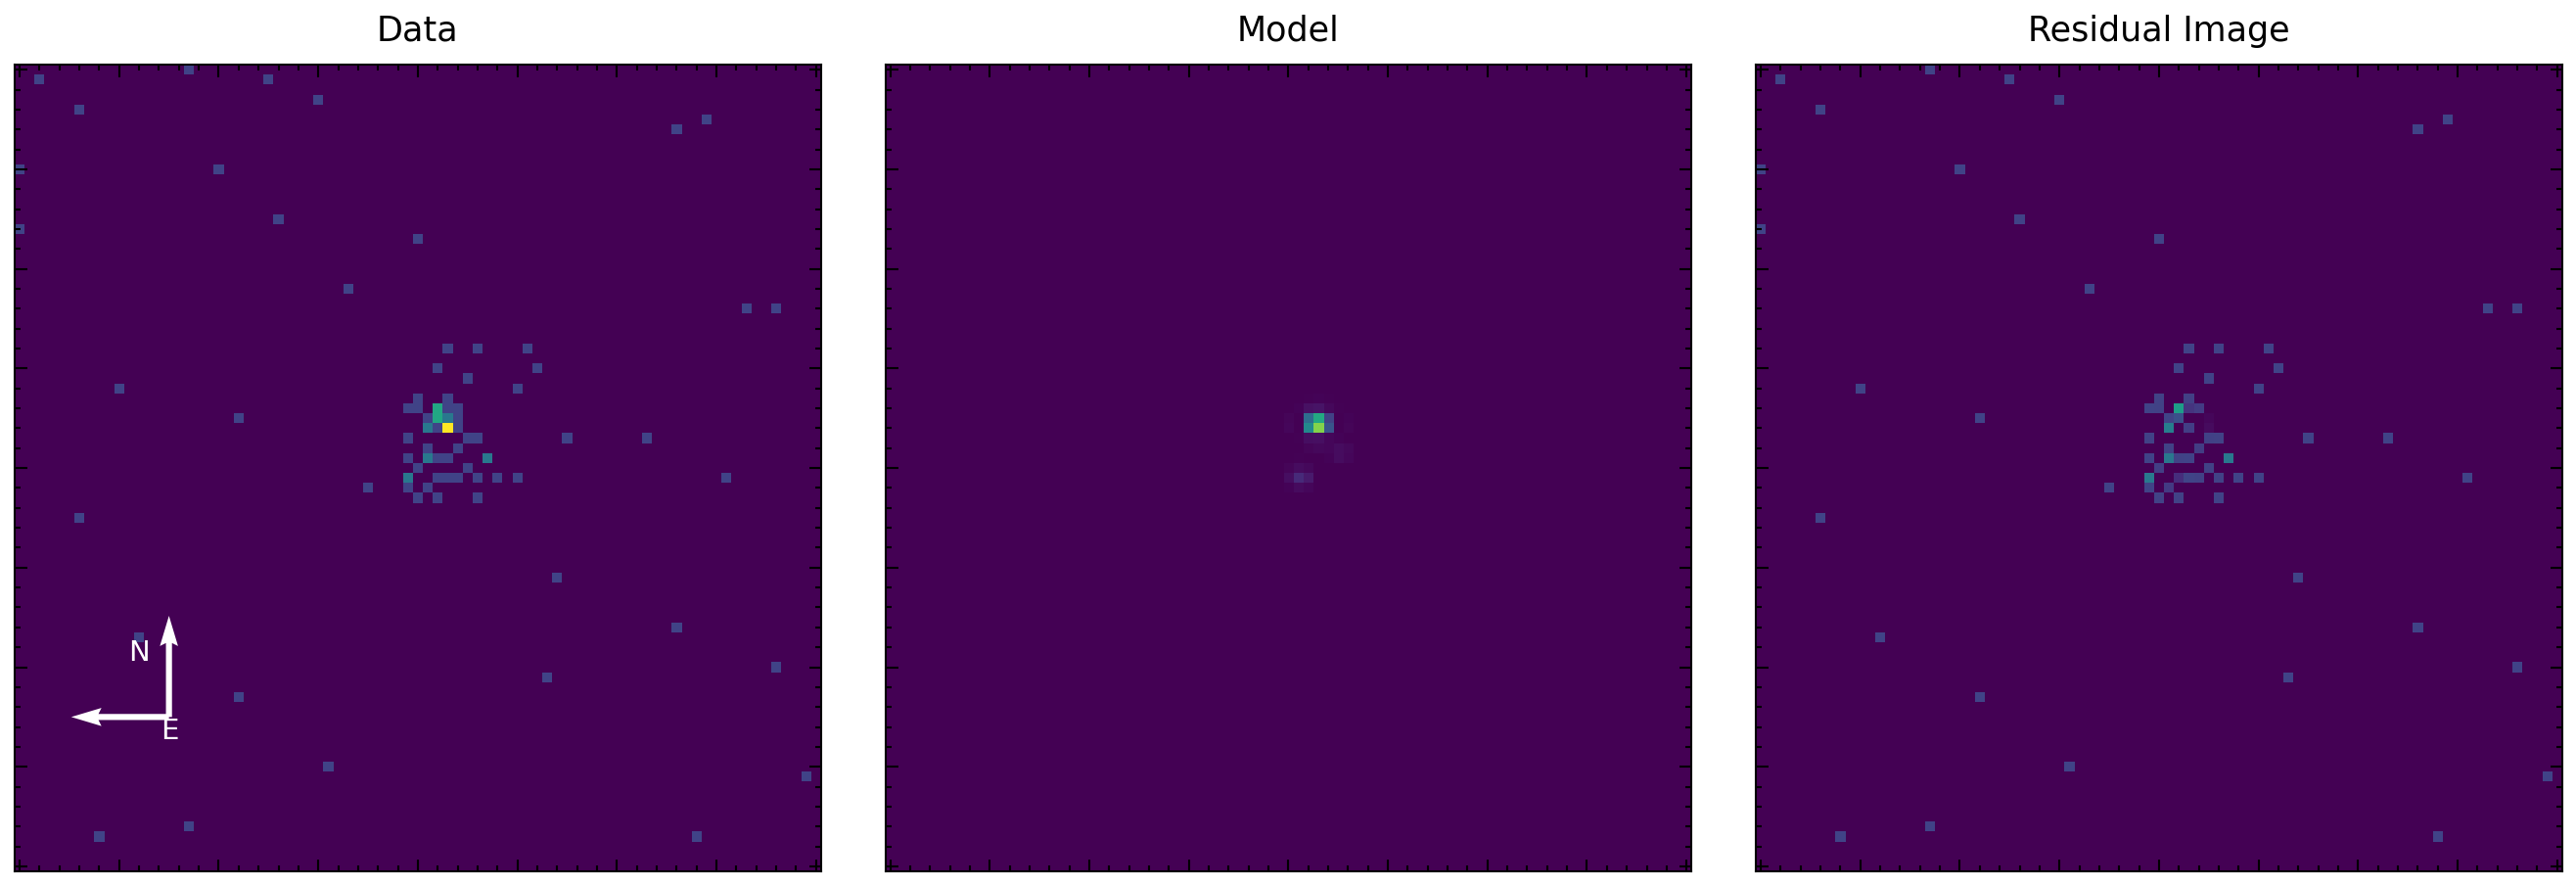

In [65]:
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":15,
"legend.fancybox":True})

# Create a constraint for fixed relative positions
def tie_xini_1(x):
    return x.x_0_0 +x_offset1
def tie_xini_2(x):
    return x.x_0_0 +x_offset2

def tie_yini_1(x):
    return x.y_0_0 +y_offset1
def tie_yini_2(x):
    return x.y_0_0 +y_offset2

for ne in [0]:
    # ne:energy range, 0:0.5-7, broadband;  1:0.5-2.0 keV; 2: 2.-7. keV
    chdu=fits.open(cpspath+f"/{pnumber}_{erange[ne]}_flux.img")

    imagecut=True

    #43.507395, 14.976920

    plt.style.use(["science",'no-latex'])
    plt.rcParams.update({
        "font.family": "dejavu sans",   # specify font family here
        "font.serif": ["Times"],  # specify font here
        "font.size":7,
    "legend.fancybox":True})

    cutsize_arcsec=40 #arcsec
    wcsall=WCS(chdu[0].header)
    sc = SkyCoord(ra=RA[0], dec=DEC[0], unit='deg',frame='icrs', equinox='J2000')
    # Calculate the size of the cutout in pixels
    pix_scale = wcsall.pixel_scale_matrix[1, 1] * 3600  # scale in arcsec/pixel
    cutsize_pixels = cutsize_arcsec / pix_scale

    # Create a cutout around the target coordinates
    if imagecut:
        try:
            image = Cutout2D(chdu[0].data, sc, size=cutsize_pixels, wcs=wcsall)
            wcs=image.wcs
        except:
            print("source(s) not found")
    else:
        image=chdu[0]
        wcs=wcsall
    wcsinfo=wcs


    ##=======================PSF fitting setup=================#

    bkgstat = MMMBackground()
    localbkg_estimator = LocalBackground(10, 40, bkgstat)

    fit_shape = [5,5]
    finder = DAOStarFinder(6.0, 2.0)
    #Do iterative PSF photometry
    

    init_params = QTable()

    xini=[]
    yini=[]
    for ind,ra in enumerate(RA):
     #   if ne==1 and ind==1:
      #      continue
        sc = SkyCoord(ra=ra, dec=DEC[ind], unit='deg',frame="icrs", equinox='J2000')
        s_coord=wcsinfo.world_to_pixel(sc)
        xini.append(s_coord[0].flatten()[0])
        yini.append(s_coord[1].flatten()[0])
    init_params['x'] = xini
    init_params['y'] = yini
    
    x_offset1, y_offset1 = xini[1] - xini[0], yini[1] - xini[0]
    x_offset2, y_offset2 = xini[2] - xini[0], yini[2] - xini[0]

    # Combine the PSF models
    

    combined_psf = psf_model.copy() + psf_model.copy() + psf_model.copy()
    combined_psf.x_0_0=xini[0]
    combined_psf.y_0_0=yini[0]
    combined_psf.x_0_0.bounds=[30,50]
    combined_psf.y_0_0.bounds=[30,50]
    combined_psf.y_0_0.fixed=False
    combined_psf.x_0_1.tied=tie_xini_1
    combined_psf.y_0_1.tied=tie_yini_1
    combined_psf.x_0_2.tied=tie_xini_2
    combined_psf.y_0_2.tied=tie_yini_2
    combined_psf.flux_0=np.max(image.data)
    combined_psf.flux_1=np.max(image.data)
    combined_psf.flux_2=np.max(image.data)
    
    # Combine the PSF models with tied offsets
    psf_model_1 = psf_model.copy()
    psf_model_2 = psf_model.copy()
    psf_model_3 = psf_model.copy()

    psf_model_1.x_0 = xini[0]
    psf_model_1.y_0 = yini[0]
    psf_model_1.flux = np.max(image.data)

    psf_model_2.x_0.tied = lambda model: model.x_0_0 + x_offset1
    psf_model_2.y_0.tied = lambda model: model.y_0_0 + y_offset1
    psf_model_2.flux = np.max(image.data)

    psf_model_3.x_0.tied = lambda model: model.x_0_0 + x_offset2
    psf_model_3.y_0.tied = lambda model: model.y_0_0 + y_offset2
    psf_model_3.flux = np.max(image.data)
    #combined_psf = psf_model_1 + psf_model_2 + psf_model_3
    #combined_psf=psf_model
    imdata=image.data
    y, x = np.mgrid[:imdata.shape[0], :imdata.shape[1]]
    fitter = fitting.LevMarLSQFitter()
    #combined_psf.x_0.bounds=[30,50]
    fit_model = fitter(combined_psf, x, y, z=imdata,maxiter=1000)
    fitted_data = fit_model(x, y)
    resid = imdata - fitted_data
    #psfphot = PSFPhotometry(combined_psf, fit_shape, finder=finder,localbkg_estimator=localbkg_estimator,
    #                        aperture_radius=2,fitter_maxiters=500)
    #phot = psfphot(imdata,init_params=init_params)


    #resid = psfphot.make_residual_image(image.data, (49, 49))
    #resid -= np.mean(phot["local_bkg"])
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 3),dpi=300)
    #norm = vis.simple_norm(imdata, 'linear', percent=99)
    _, med, std = sigma_clipped_stats(imdata)
    norm = vis.ImageNormalize(vmin = 0, vmax = np.max(imdata),stretch = vis.LinearStretch())

    ax[0].imshow(imdata, origin='lower', norm=norm)
    ax[1].imshow(imdata - resid, origin='lower', norm=norm)
    im = ax[2].imshow(resid, origin='lower',norm=norm)
    ax[0].set_title('Data')
    ax[1].set_title('Model')
    ax[2].set_title('Residual Image')


    x0, y0 = 15, 15
    arrow_length = 5/3600

    # Convert pixel coordinates to sky coordinates (RA, Dec)
    sky_coords = wcsinfo.pixel_to_world(x0, y0)
    ra, dec = sky_coords.ra.deg, sky_coords.dec.deg

    # Define the end points of the arrows in pixel coordinates
    north_end = wcsinfo.world_to_pixel_values(ra, dec + arrow_length)
    east_end = wcsinfo.world_to_pixel_values(ra + arrow_length, dec)


    # Calculate the direction vectors for the arrows
    north_vector = [north_end[0] - x0, north_end[1] - y0]
    east_vector = [east_end[0] - x0, east_end[1] - y0]

    # Plot the North arrow
    ax[0].quiver(x0, y0, north_vector[0], north_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
    ax[0].text(x0 + north_vector[0]/2-3, y0 + north_vector[1]/2, 'N', color='w', ha='center', va='bottom')

    # Plot the East arrow
    ax[0].quiver(x0, y0, east_vector[0], east_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
    ax[0].text(x0 + east_vector[0]/2+5, y0 + east_vector[1]/2, 'E', color='w', ha='center', va='top')
    for ind,ra in enumerate(RA):
        sc = SkyCoord(ra=ra, dec=DEC[ind], unit='deg',frame="icrs", equinox='J2000')
        s_coord=wcsinfo.world_to_pixel(sc)
        #ax[1].plot(s_coord[0], s_coord[1],"+",c="m",ms=8,lw=0.1)
    for axx in ax:
        axx.set_xticklabels([])
        axx.set_yticklabels([])
    #fig.savefig(multiAGNpath+"/"+field+"/fig/{}_{}_{}.pdf".format(datatype,inst.split("/")[0],inst.split("/")[1]))
    plt.tight_layout()
    
    cov_matrix = fitter.fit_info['param_cov']
    std_devs = np.sqrt(np.diag(cov_matrix))

    #phot.sort("y_init")
    # 3 objects, write Lx
    fac=1/p2e[ne][0]*p2e[ne][1]*4*np.pi*Planck18.luminosity_distance(0.03145).to(u.cm).value**2
    Lxerr[erange[ne]]=np.array([std_devs[0]]+[std_devs[i] for i in range(3,5)])*fac
    Lx[erange[ne]]=[fit_model[i].flux*fac for i in range(3)]
    fig.savefig(cdata+"/{}_{}_{}_fitted.pdf".format(psname,erange[ne],pnlist[npn]))


Lxall[pnlist[npn]]=[Lx.copy(),Lxerr.copy()]
'''
_, med, std = sigma_clipped_stats(chdu[0].data)
med=np.mean(chdu[0].data)
std=np.std(chdu[0].data)

norm = vis.ImageNormalize(vmin = med, vmax = med+3*std)

fig, ax = plt.subplots(subplot_kw={'projection': wcs},figsize=(5,3),dpi=300)
ax.imshow(image.data,norm=norm)

#-------------------Reference scale setting----------------#
dT = 4  # kpc distance
delta_theta_deg = dT/Planck18.kpc_proper_per_arcmin(redshift).value/60
delta_arcsec = delta_theta_deg*3600
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()
start_x = x_lim[0] + 0.10 * (x_lim[1] - x_lim[0])
start_y = y_lim[0] + 0.10 * (y_lim[1] - y_lim[0])
start_coord = wcsall.pixel_to_world(start_x, start_y)
end_coord = wcsall.pixel_to_world(start_x + 1, start_y)  # arbitrary +1 in pixel to get RA difference for 1 pixel

delta_ra_per_pixel = start_coord.ra.degree - end_coord.ra.degree
length_in_pixels = delta_theta_deg / delta_ra_per_pixel

#length_in_pixels2 = delta_theta_deg2 / delta_ra_per_pixel

#ax.plot([start_x, start_x + length_in_pixels2], [start_y-1, start_y-1], color='white', lw=2)

ax.plot([start_x, start_x + length_in_pixels], [start_y, start_y], color='white', lw=2)
ax.text(start_x + length_in_pixels / 2, start_y*1.2, '{} kpc'.format(dT), color='white', ha='center', va='bottom')
ax.text(start_x + length_in_pixels / 2, start_y*1.6, '{:.2f} arcsec'.format(delta_arcsec), color='white', ha='center', va='bottom')

pixel_region = [cr[i].to_pixel(wcs) for i in range(len(cr))]
#for i,reg in enumerate(pixel_region):
#    reg.plot(origin=(0, 0),ax=ax,color="C{}".format(i),label="Obj.{}".format(i))
'''

#r_pixreg=r_total.to_pixel(wcs)
#r_pixreg.plot(origin=(0, 0),ax=ax,color="g",label="source")

#br_pixreg=br.to_pixel(wcs)
#br_pixreg.plot(origin=(0, 0),ax=ax,color="r",label="Background region")
'''
ax.legend(labelcolor="white")

ax.set_xlabel("R.A.")
ax.set_ylabel("Dec.")
#if re.findall(r"606W.+",dataname):
    #ax.invert_xaxis()
#ax.set_title("UGC 2369s")
#pixsc=wcs.world_to_pixel(sc)
#ax.plot(pixsc[0],pixsc[1],"ro",markeredgewidth=.1,lw=0.01)
#plt.scatter(pixsc[0],pixsc[1], s=55, facecolors='none', edgecolors='r')
#ax.plot(43.507395, 14.976920,"+", transform=ax.get_transform('world'),c="g",ms=30,lw=0.1)

for io in range(len(RA)):
    ax.plot(RA[io], DEC[io],"+", transform=ax.get_transform('world'),c="g",ms=5,lw=0.1)
    #ax.text(RA[io], DEC[io],"UGC 2369",color="g",transform=ax.get_transform('world'),verticalalignment='bottom',horizontalalignment='right',fontsize=15)
#fig.savefig(datapath+"/fig/{}S_chandra.pdf".format(psname1+psname2))
'''

In [870]:
SFR["Ha"]=[5.66,6.79,8.93]
SFR["33GHz"]=[2.63,3.55,14.7]
F33GHz=np.array([0.035,0.035,0.68])*1e-26*33e9
L33GHz=F33GHz*4*np.pi*Planck18.luminosity_distance(0.03145).to(u.cm).value**2
SFRmethod="33GHz"
band="hard"
print(f"expected X-ray luminosity in {band} band from SFR:")
print("Using",SFRmethod,"as SFR estimator")
Lxmethod={"0.5-2.0":39.83+0.74*np.log10(SFR[SFRmethod])+0.97*np.log10(1+0.03145)\
          ,"hard":39.82+0.63*np.log10(SFR[SFRmethod])+1.31*np.log10(1+0.03145)}
print(10**Lxmethod[band])
print("observed Lx:")
print(Lxall["28148"][0][erange[ne]])
print("error:")
print(Lxall["28148"][1][erange[ne]])
print("radio derived coronal X-ray luminosity")
print(10**((np.log10(L33GHz)-9.88)/0.67))

expected X-ray luminosity in hard band from SFR:
Using 33GHz as SFR estimator
[1.26528756e+40 1.52848429e+40 3.74133879e+40]
observed Lx:
[2.345637065120781e+38, 2.2388631190837537e+38, 1.0726610495521233e+40]
error:
[4.17382136e+39 4.35154138e+39 4.35280696e+39]
radio derived coronal X-ray luminosity
[1.40609755e+41 1.40609755e+41 1.17777281e+43]


In [871]:
L33GHz

array([2.81300402e+37, 2.81300402e+37, 5.46526495e+38])

In [872]:
Lxall["28148"][0][erange[ne]]

[2.345637065120781e+38, 2.2388631190837537e+38, 1.0726610495521233e+40]

In [874]:
np.log10(L33GHz*0.3897/Lxall["28148"][0][erange[ne]])

array([-1.33036006, -1.31012678, -1.70212088])

In [108]:
print(np.array(Lxall["28148"][0][erange[ne]])*4.136e8/(10-2))

[ 6.08078665e+47 -2.22735278e+45  4.84431649e+47]


In [110]:
Lxall["28148"][0][erange[ne]]

[1.1761676309633224e+40, -4.308225874976184e+37, 9.370051230642652e+39]

2.6652282065506935e+39 2.778712795834648e+39 6.849565989152961e+39
2.6652282065506935e+39 2.778712795834648e+39 2.779520943090384e+39
[True, True, False]
4.706593138188272e+39 4.1929133345672896e+39 1.7645908780102206e+40
4.246975418941746e+39 4.1929133345672896e+39 4.25848022389858e+39
[True, True, False]
1.1761676309633224e+40 3.613439544860776e+39 9.370051230642652e+39
3.6161351089281596e+39 3.613439544860776e+39 3.682847436567679e+39
[True, True, False]


(1e+36, 5e+40)

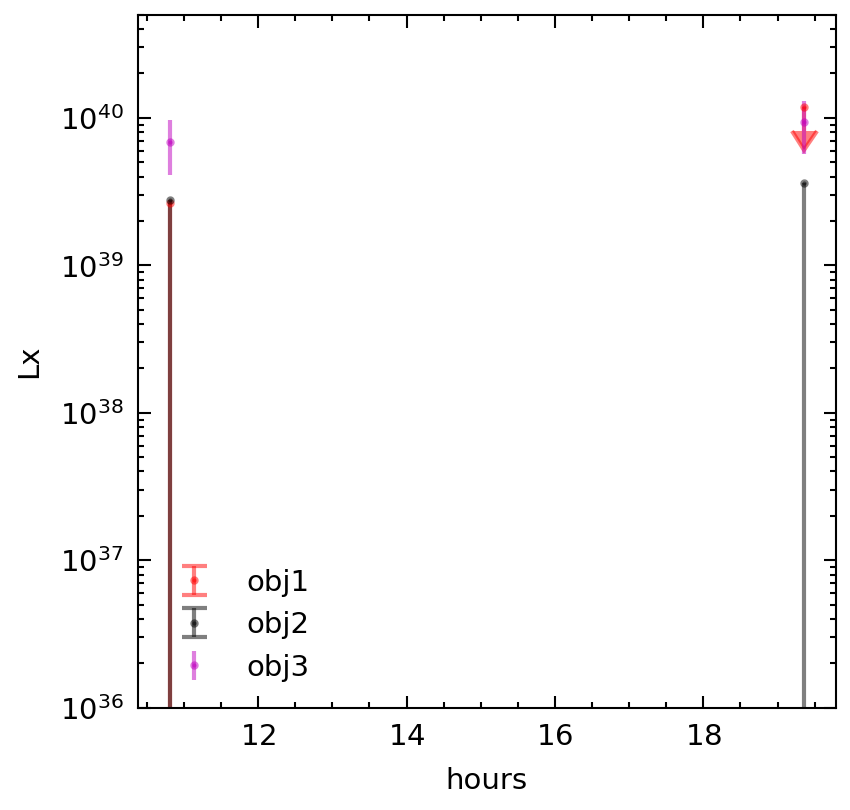

In [120]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3),dpi=300)
uplims=[False]*3
band="hard"

ebararg={"ms":1.,
            "capsize":0.0,
            "ls":"None",
            "alpha":0.5,
            "lw":1}
for prop in Lxall.keys():
    
    yobj1err=Lxall[prop][1][band][0]
    yobj2err=Lxall[prop][1][band][1]
    yobj3err=Lxall[prop][1][band][2]
    
    for objind,objerr in enumerate(Lxall[prop][1][band]):
        if objerr >= Lxall[prop][0][band][objind]:
            uplims[objind]=True
            Lxall[prop][0][band][objind]=objerr
            
    yobj1=Lxall[prop][0][band][0]
    yobj2=Lxall[prop][0][band][1]
    yobj3=Lxall[prop][0][band][2]
    print(yobj1,yobj2,yobj3)
    print(yobj1err,yobj2err,yobj3err)
    print(uplims)
  #  print(prop)
    if prop=="04058":
        continue
      #  prop="4058"
    chdu=fits.open(cpspath+f"/{prop}_broad_flux.img")
    time=(chdu[0].header["MJD-OBS"]-60281)*24
    #print(time)
    if prop == "28148":
        ax.errorbar(time,yobj1,yerr=yobj1err,uplims=uplims[0],fmt="or",label="obj1",**ebararg)
        ax.errorbar(time,yobj2,yerr=yobj2err,uplims=uplims[1],fmt="ok",label="obj2",**ebararg)
        ax.errorbar(time,yobj3,yerr=yobj3err,uplims=uplims[2],fmt="om",label="obj3",**ebararg)
    else:
        ax.errorbar(time,yobj1,yerr=yobj1err,uplims=uplims[0],fmt="or",**ebararg)
        ax.errorbar(time,yobj2,yerr=yobj2err,uplims=uplims[1],fmt="ok",**ebararg)
        ax.errorbar(time,yobj3,yerr=yobj3err,uplims=uplims[2],fmt="om",**ebararg)
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("hours")
ax.set_ylabel("Lx")
ax.set_ylim([1e36,5e40])

In [630]:
0.75/pix_scale

1.524390243902402

#### Do aperture photometry for combined image

 id      xcenter           ycenter        aperture_sum
           pix               pix                      
--- ----------------- ------------------ -------------
  1 39.45123170673094 41.166425555588305 1.8267292e-05
  3 44.85241205615596  42.86741737875115 1.8496199e-05
  2 41.98451797699315  45.16340039450902 1.8364533e-05


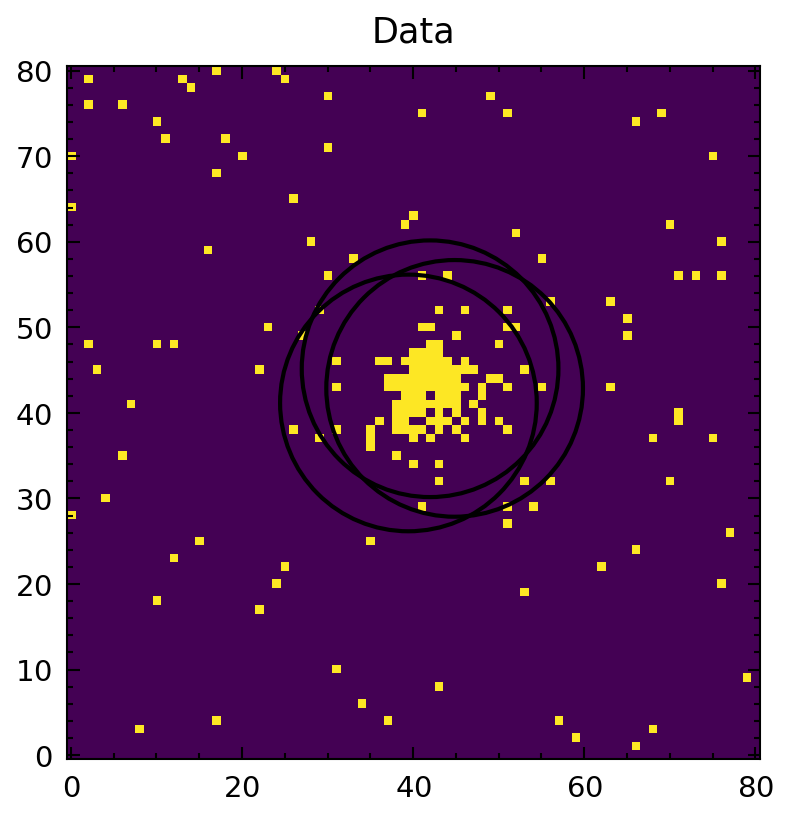

In [67]:
root=os.path.join(cdata,psname)
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry

positions=np.array([(fit_model[i].y_0.value,fit_model[i].x_0.value) for i in range(3)])
aper = CircularAperture(positions,r=0.75/pix_scale)

br_aper = CircleAnnulusPixelRegion(PixCoord(positions[1][0],positions[1][1]), 4/pix_scale, 40/pix_scale)


for ne in [0]:
    # ne:energy range, 0:0.5-7, broadband;  1:0.5-2.0 keV; 2: 2.-7. keV
    chdu=fits.open(cpspath+f"/{erange[ne]}_flux.img")

    imagecut=True

    #43.507395, 14.976920

    plt.style.use(["science",'no-latex'])
    plt.rcParams.update({
        "font.family": "dejavu sans",   # specify font family here
        "font.serif": ["Times"],  # specify font here
        "font.size":7,
    "legend.fancybox":True})

    cutsize_arcsec=40 #arcsec
    wcsall=WCS(chdu[0].header)
    sc = SkyCoord(ra=RA[0], dec=DEC[0], unit='deg',frame='icrs', equinox='J2000')
    # Calculate the size of the cutout in pixels
    pix_scale = wcsall.pixel_scale_matrix[1, 1] * 3600  # scale in arcsec/pixel
    cutsize_pixels = cutsize_arcsec / pix_scale

    # Create a cutout around the target coordinates
    if imagecut:
        try:
            image = Cutout2D(chdu[0].data, sc, size=cutsize_pixels, wcs=wcsall)
            wcs=image.wcs
        except:
            print("source(s) not found")
    else:
        image=chdu[0]
        wcs=wcsall
    wcsinfo=wcs
    chandra_comb_wcs=image.wcs
    imdata=image.data
    phot_table = aperture_photometry(imdata, aper)
    phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
    phot_table.sort("ycenter")
    print(phot_table)
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3),dpi=300)
    _, med, std = sigma_clipped_stats(imdata)
    norm = vis.ImageNormalize(vmin = 0, vmax = 2*np.nanstd(imdata),stretch = vis.LogStretch())

    ax.imshow(imdata, origin='lower', norm=norm)
    for i,naper in enumerate(aper):
        naper.plot(ax=ax)
    
    ax.set_title('Data')
br_aper.plot(ax=ax)

In [642]:
std

0.0

In [859]:
fac=1/p2e[ne][0]*p2e[ne][1]
lfac=4*np.pi*Planck18.luminosity_distance(0.03145).to(u.cm).value**2*fac
flux_aper=phot_table['aperture_sum']*fac
lum_aper=phot_table['aperture_sum']*lfac

In [860]:
SFR

{'Ha': [5.66, 6.79, 8.93], '33GHz': [2.63, 3.55, 14.7]}

In [861]:

band="hard"
print(f"expected X-ray luminosity from SF in {band} band from SFR:")
print("Using",SFRmethod,"as SFR estimator")
Lxmethod={"0.5-2.0":39.83+0.74*np.log10(SFR[SFRmethod])+0.97*np.log10(1+0.03145)\
          ,"hard":39.82+0.63*np.log10(SFR[SFRmethod])+1.31*np.log10(1+0.03145)}
print(10**Lxmethod[band])
print(f"measured {band} X-ray luminosity:")
print(lum_aper.data)

expected X-ray luminosity from SF in hard band from SFR:
Using 33GHz as SFR estimator
[1.26528756e+40 1.52848429e+40 3.74133879e+40]
measured hard X-ray luminosity:
[5.81530073e+39 2.07360016e+39 1.34329322e+40]


In [863]:
41.9279-np.log10(lum_aper.data)

array([2.16332782, 2.61117498, 1.79972918])

In [6]:
import xspec
#xspec.plt.clf()

lw = 2   # Line widths throughout the plot
fsz = 16 # Font size throughout the plot

specpath=cdata+"/"+psname+"/stack/obj3/"

#xspec.plt.rc('axes', labelsize=14)  # fontsize of the x any y labels

# Load local models
#AllModels.lmod("relxill")

# Energies
#AllModels.setEnergies("/disk/bifrost/yuanze/my_work/pub3/specE_n{}_logxi_{}.txt".format(density,logxi))
# Define the Model
#m1 = Model("atable{/disk/bifrost/yuanze/reflionx/reflionx_HD_nthcomp_v2.fits}")
os.chdir(specpath)
xspec.Xset.restore("obj3_apec.xcm")
#xspec.AllModels.setEnergies("0.2 10. 980 linear")
xspec.Plot.setRebin(minSig=1,maxBins=1000,groupNum=-1,errType="quad")

xspec.Plot("euf ra emo ld back")
xda = np.array(xspec.Plot.x())
xdaerr = np.array(xspec.Plot.xErr())
xmo = np.array(xspec.Plot.x(plotWindow=3))
mo = np.array(xspec.Plot.model(plotWindow=3))

addcomp1=np.array(xspec.Plot.addComp(addCompNum=1, plotGroup=1, plotWindow=3))
addcomp2=np.array(xspec.Plot.addComp(addCompNum=2, plotGroup=1, plotWindow=3))


yda = np.array(xspec.Plot.y())
ydaerr = np.array(xspec.Plot.yErr())
yra  = np.array(xspec.Plot.y(plotWindow=2))
yraerr  = np.array(xspec.Plot.yErr(plotWindow=2))

xback = np.array(xspec.Plot.x(plotWindow=5))
xbackerr = np.array(xspec.Plot.xErr(plotWindow=5))

yback = np.array(xspec.Plot.y(plotWindow=5))
ybackerr = np.array(xspec.Plot.yErr(plotWindow=5))

xld = np.array(xspec.Plot.x(plotWindow=4))
yld = np.array(xspec.Plot.y(plotWindow=4))
ylderr = np.array(xspec.Plot.yErr(plotWindow=4))

Default fit statistic is set to: C-Statistic
   This will apply to all current and newly loaded spectra.

***Warning: The file sent to Xset.restore(): obj3_apec.xcm
    is not detected to be a file generated from Xset.save().
    Xset.restore() usage is only intended for Xset.save() output.
    General XSPEC/Tcl scripts may not fully execute in PyXspec.



1 spectrum  in use
 
Spectral Data File: combined_src_bin.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  5.961e-04 +/- 1.199e-04 (97.5 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-664
  Telescope: CHANDRA Instrument: ACIS  Channel Type: PI
  Exposure Time: 4.253e+04 sec
 Using fit statistic: cstat
 Using Background File                combined_bkg.pi
  Background Exposure Time: 4.253e+04 sec
 Using Response (RMF) File            combined_src.rmf for Source 1
 Using Auxiliary Response (ARF) File  combined_src.arf

    23 channels (1,23) ignored in spectrum #     1
   463 channels (202,664) ignored 

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.


 0.0          
________________________________________________________________________

Reading APEC data from 3.0.9


Fit statistic  : C-Statistic                   83.30     using 178 bins.

Test statistic : Chi-Squared              3.118074e+07     using 178 bins.
 Null hypothesis probability of 0.000000e+00 with 173 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : C-Statistic                   83.30     using 178 bins.

Test statistic : Chi-Squared              3.118074e+07     using 178 bins.
 Null hypothesis probability of 0.000000e+00 with 173 degrees of freedom
 Current data and model not fit yet.
***Warning: Fit is not current.
***Warning: Fit is not current.
***Warning: Fit is not current.


(0.1, 6.0)

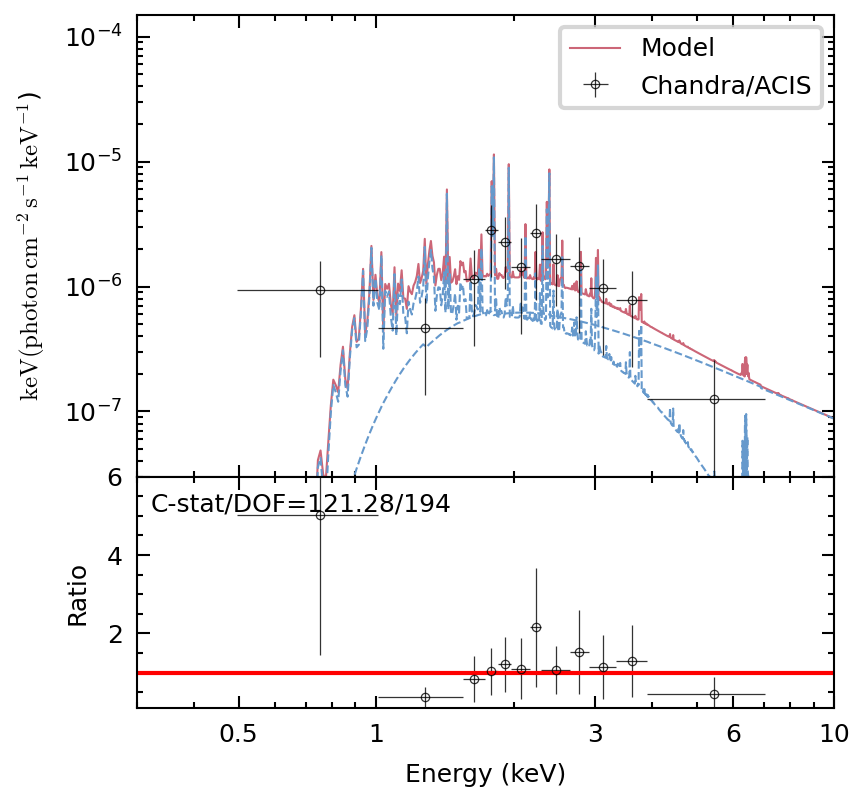

In [7]:
#Ploting spectra for publication
import scienceplots
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":6,
"legend.fancybox":True})
z=1.285
lw=0.5
numrow=2
numcol=1
colorlst=["#CC6677","#88CCEE","#6699CC"]
fig=plt.figure(figsize=(3,3),dpi=300)
gs = fig.add_gridspec(numrow, numcol,height_ratios=[2,1],hspace=0.0)
axs=gs.subplots(sharex=True)

axs[0].plot(xmo,mo,color=colorlst[0],ms=0.5,label="Model",lw=lw)
axs[0].plot(xmo,addcomp1,color=colorlst[2],ms=0.5,ls="--",lw=lw)
axs[0].plot(xmo,addcomp2,color=colorlst[2],ms=0.5,ls="--",lw=lw)

axs[0].errorbar(xda,yda,xerr=xdaerr,yerr=ydaerr,fmt="ko",mfc="none",mew=0.3,ms=2,lw=0.3,alpha=0.8,label="Chandra/ACIS")

axs[1].errorbar(xda,yra,xerr=xdaerr,yerr=yraerr,fmt="ko",mfc="none",mew=0.3,ms=2,lw=0.3,alpha=0.8)

#axs.set_xscale("log")
axs[0].legend(frameon=True)
axs[1].set_ylabel("Ratio")

axs[1].text(0.02,0.85,r"C-stat/DOF=121.28/194",transform=axs[1].transAxes)
#axs[1].set_ylim([0,7.5])
axs[1].axhline(1,color="r")
axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[1].set_xlabel("Energy (keV)")
axs[0].set_ylabel(r"$\rm keV(photon\,cm^{-2}\,s^{-1}\,keV^{-1}$)")
axs[0].set_xlim([0.3,10])
axs[0].set_ylim([3e-8,1.5e-4])
xarray=[0.5,1,3,6,10]
axs[1].set_xticks(xarray)
axs[1].set_xticklabels(xarray)
axs[1].set_ylim(0.1,6.0)
#plt.axvline(x=)
#axs=plt.gca()
#axs[0].text(0.05,0.92,r"$n=10^{%s}\,$cm$^{-3}$"%density,transform=axs[0].transAxes)
#axs[0].text(0.05,0.87,r"Log$[\,\xi/$erg$\,$cm$\,$s$^{-1}]=%s $"%logxi,transform=axs[0].transAxes)


#fig.savefig("/disk/bifrost/yuanze/multiAGN/UGC2369/fig/chandra_spec.pdf")

(0.5, 3.0)

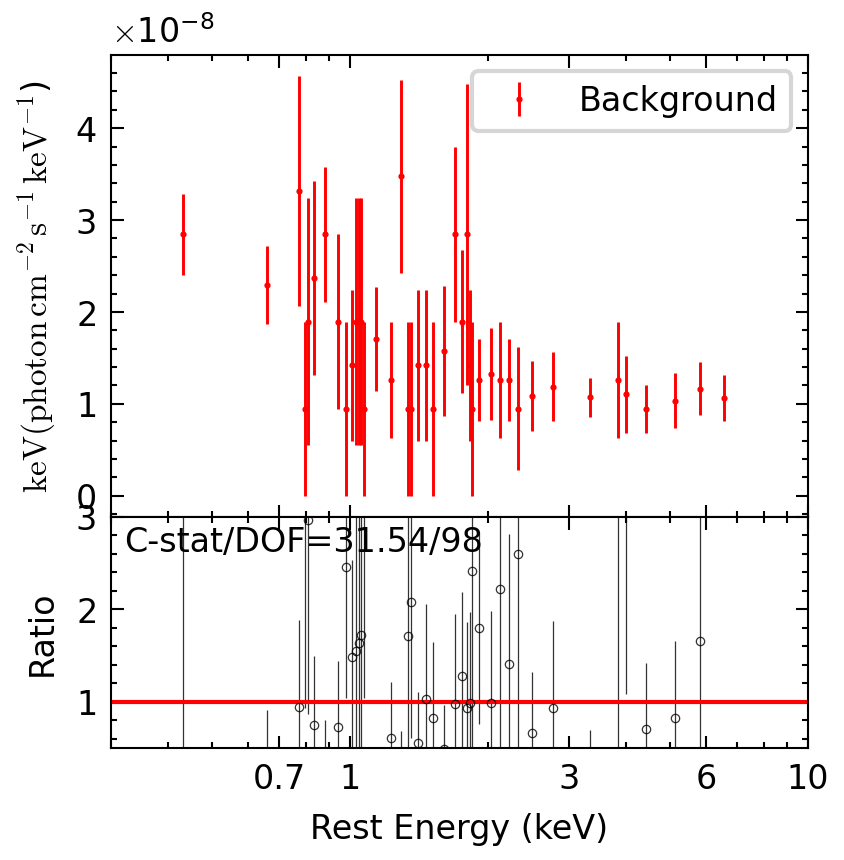

In [677]:
#Ploting spectra for publication
import scienceplots
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":8,
"legend.fancybox":True})
z=1.285
lw=0.7
numrow=2
numcol=1
colorlst=["#CC6677","#88CCEE","#6699CC"]
fig=plt.figure(figsize=(3,3),dpi=300)
gs = fig.add_gridspec(numrow, numcol,height_ratios=[2,1],hspace=0.0)
axs=gs.subplots(sharex=True)


#axs[0].errorbar(xld,yld,yerr=ylderr,fmt="ko",mfc="none",mew=0.3,ms=2,lw=0.3,alpha=0.8,label="Chandra/ACIS")
axs[0].errorbar(xda,yback,yerr=ybackerr,fmt="o",color="r",ms=0.5,label="Background",lw=lw)
axs[1].errorbar(xda,yra,yerr=yraerr,fmt="ko",mfc="none",mew=0.3,ms=2,lw=0.3,alpha=0.8)

#axs.set_xscale("log")
axs[0].legend(frameon=True)
axs[1].set_ylabel("Ratio")

axs[1].text(0.02,0.85,r"C-stat/DOF=31.54/98",transform=axs[1].transAxes)
#axs[1].set_ylim([0,7.5])
axs[1].axhline(1,color="r")
#axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[1].set_xlabel("Rest Energy (keV)")
axs[0].set_ylabel(r"$\rm keV(photon\,cm^{-2}\,s^{-1}\,keV^{-1}$)")
axs[0].set_xlim([0.3,10])
#axs[0].set_ylim([-1e-5,1.5e-4])
xarray=[0.7,1,3,6,10]
axs[1].set_xticks(xarray)
axs[1].set_xticklabels(xarray)
axs[1].set_ylim(0.5,3.0)
#plt.axvline(x=)
#axs=plt.gca()
#axs[0].text(0.05,0.92,r"$n=10^{%s}\,$cm$^{-3}$"%density,transform=axs[0].transAxes)
#axs[0].text(0.05,0.87,r"Log$[\,\xi/$erg$\,$cm$\,$s$^{-1}]=%s $"%logxi,transform=axs[0].transAxes)


#fig.savefig("/disk/bifrost/yuanze/multiAGN/UGC2369/fig/chandra_spec.pdf")

In [31]:
np.savetxt(cpspath+"/spec.txt",np.array([x,mo]).T)

In [720]:
#cstat1=87.71
#cstat2=76.35

cstat1=134.38
cstat2=121.28
k1=3
k2=5
#bins=89
bins=199
def BIC(cstat,k,N):
    return cstat+k*np.log(N)
def AIC(cstat,k):
    return cstat+2*k
def AICc(cstat,k,N):
    return AIC(cstat,k)+2*k*(k+1)/(N-k-1)

AIC2=AIC(cstat2,k2)
AIC1=AIC(cstat1,k1)

AICc2=AICc(cstat2,k2,bins)
AICc1=AICc(cstat1,k1,bins)
BIC1=BIC(cstat1,k1,bins)
BIC2=BIC(cstat2,k2,bins)

print(AIC1,AIC2)
print(AICc1,AICc2)
print(BIC1,BIC2)

140.38 131.28
140.50307692307692 131.59088082901553
150.25991447417348 147.74652412362246


In [713]:
cstat1+k1*np.log(bins)

144.96660964944897

In [707]:
AIC(cstat1,k1)

138.38

In [1004]:
np.std(chandra_image_reprojected)*10

1.5018381253729004e-07

In [41]:
Planck18.kpc_proper_per_arcmin(2.65)/60

<Quantity 8.15443677 kpc / arcmin>

## HST

### Making figure for paper

In [1224]:
datapath+"/hst/"+dataname+"/"+dataname+".fits"

'/disk/bifrost/yuanze/multiAGN/UGC2369/hst/ugc2369i/ugc2369i.fits'

In [235]:
redshift

0.0322

0.057941286079058754
[39.1838196  32.27982514]


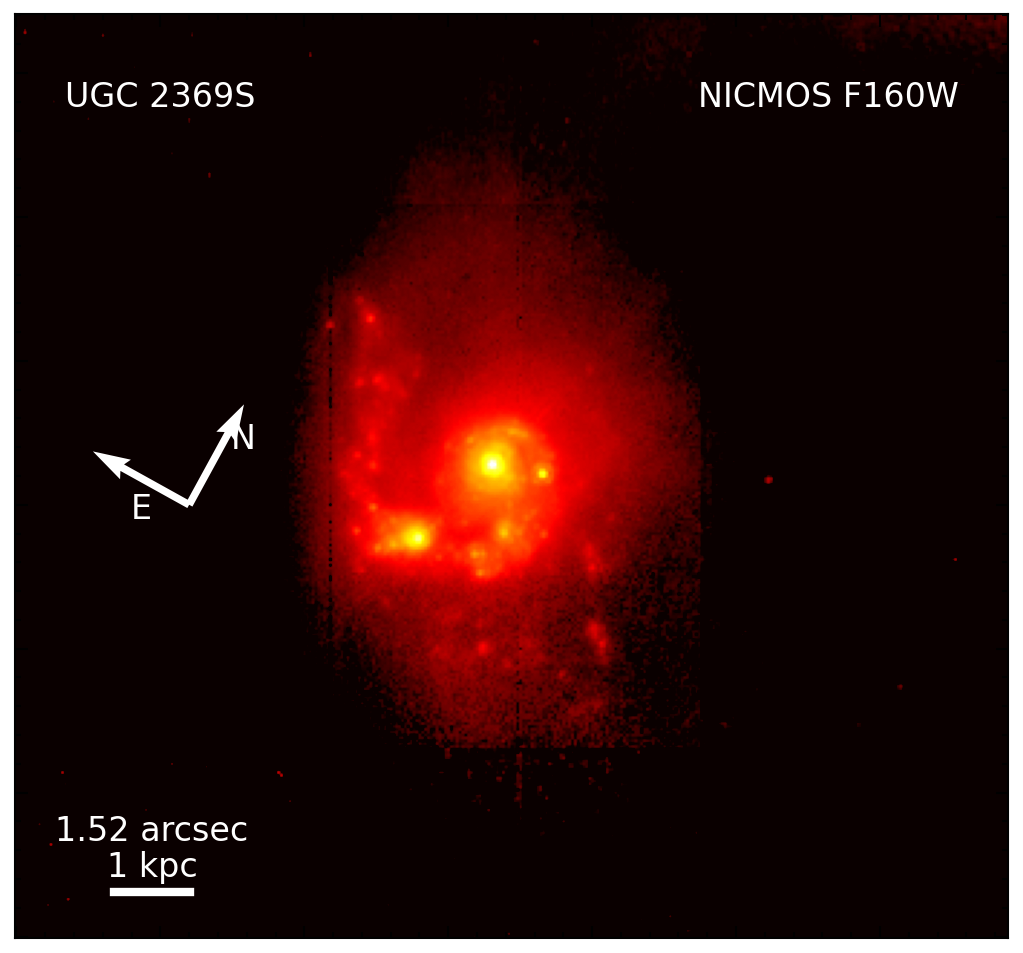

In [96]:
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":8,
"legend.fancybox":True})


imagecut=True
cutsize_arcsec=20 #arcsec
#sc3 = SkyCoord(RA[2], DEC[2], unit='deg',frame='icrs', equinox='J2000')
#tag2 = "core2"
#sc2 = SkyCoord(RA[1], DEC[1], unit='deg',frame='icrs', equinox='J2000')
tag1 = "core1"
sc = SkyCoord(np.mean(RA[2]), np.mean(DEC[2]), unit=u.deg,frame='icrs', equinox='J2000')
dataname="na1e09010"
#dataname="ugc2369i"
#dataname="hst_10592_11_acs_wfc_f435w_j9cv11"
#ava=os.listdir(hstpath+"/hst/")
#ava=["q0100_f450w.fits","q0100_f555w.fits","q0100_f814w.fits","q0100_wfc3.fits"]
#for dataname in ava:
#hdu=fits.open(datapath+"/hst/"+dataname+"/"+dataname+".fits")
hdu=fits.open(datapath+"/hst/"+dataname+"/"+dataname+"_mos.fits")
wcsall=WCS(hdu[1].header)
#print(hdu[0].header["INSTRUME"],hdu[0].header["DETECTOR"],hdu[0].header["FILTER"])

tant=wcsall.pixel_scale_matrix[0,1]/wcsall.pixel_scale_matrix[0,0]
xpix=1/np.sqrt(1+tant**2)*wcsall.pixel_scale_matrix[1,1]*3600
print(xpix)

pix_scale = xpix
#wcsall.pixel_scale_matrix[1, 1] * 3600  # scale in arcsec/pixel

# Calculate the size of the cutout in pixels
cutsize_pixels = cutsize_arcsec / pix_scale

# Create a cutout around the target coordinates
if imagecut:
 #   try:
    image = Cutout2D(hdu[1].data, sc, size=cutsize_pixels, wcs=wcsall)
    wcs=image.wcs
#    except:
#        print("source(s) not found")
#        continue
else:
    image=hdu[1].header
    wcs=wcsall
_, med, std = sigma_clipped_stats(image.data)

#wcs=new_wcs

## reproject chandra data onto this higher resolution image
from scipy.ndimage import gaussian_filter
sigma = 5  # Standard deviation of the Gaussian kernel
image_reprojected, footprint = reproject_interp((imdata, chandra_comb_wcs), image.wcs, shape_out=image.shape)
chandra_image_reprojected = gaussian_filter(image_reprojected, sigma=sigma)

#========================


norm = vis.ImageNormalize(vmin = std, vmax = med+1000*std,stretch=vis.stretch.LogStretch())

fig, ax = plt.subplots(figsize=(8,4),dpi=300)#subplot_kw={'projection': wcs}
ax.imshow(image.data,norm=norm,cmap="hot",origin="lower")

cnorm = vis.ImageNormalize(vmin = np.nanmedian(chandra_image_reprojected)+np.nanstd(chandra_image_reprojected), vmax = np.max(chandra_image_reprojected),stretch=vis.stretch.LogStretch())
chandra_image_reprojected[chandra_image_reprojected<=0]=np.std(chandra_image_reprojected)
#ax.contour(chandra_image_reprojected,norm=cnorm,levels=5,linewidths=0.5,cmap="Blues")


#if re.findall(r"606W.+",dataname):
    #ax.invert_xaxis()
#ax.set_title(dataname)


det_array=image.data.copy(order="C").byteswap().newbyteorder()

bkg=sep.Background(det_array)
bkg_image = bkg.back()
data_sub = det_array - bkg
objects = sep.extract(det_array, 3,minarea=100, err=std)
objects.sort(order=('y'))

rex=0.75/pix_scale
#plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
r, flag = sep.flux_radius(det_array, objects['x'], objects['y'], 6.*objects['a'], 0.5)
print(r)
"""
for i in range(len(objects[:3])):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=2*rex,#2*objects['a'][i],
                height=2*rex,#2*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi,ls="--")
    
    e.set_facecolor('none')
    e.set_edgecolor('white')
    e.set_linewidth(0.5)
    ax.add_artist(e)
    ax.text(objects['x'][i]*1.1,objects['y'][i]*1.1,"Object {:d}".format(i+1),horizontalalignment="center",va="center",color="white",fontsize=6)
"""

#-------------------Reference scale setting----------------#
dT = 1  # kpc distance
delta_theta_deg = dT/Planck18.kpc_proper_per_arcmin(0.0318).value/60
delta_arcsec = delta_theta_deg*3600
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()
start_x = x_lim[0] + 0.10 * (x_lim[1] - x_lim[0])
start_y = y_lim[0] + 0.05 * (y_lim[1] - y_lim[0])
#start_coord = wcsall.pixel_to_world(start_x, start_y)
#end_coord = wcsall.pixel_to_world(start_x + 1, start_y)  # arbitrary +1 in pixel to get RA difference for 1 pixel

#delta_ra_per_pixel = start_coord.ra.degree - end_coord.ra.degree
delta_ra_per_pixel=pix_scale/3600
length_in_pixels = delta_theta_deg / delta_ra_per_pixel

ax.plot([start_x, start_x + length_in_pixels], [start_y, start_y], color='white', lw=2)
#ax.text(start_x + length_in_pixels / 2, start_y*1.2, '{} pc'.format(int(dT*1000)), color='white', ha='center', va='bottom')
ax.text(start_x + length_in_pixels / 2, start_y*1.2, '{} kpc'.format(dT), color='white', ha='center', va='bottom')
ax.text(start_x + length_in_pixels / 2, start_y*2, '{:.2f} arcsec'.format(delta_arcsec), color='white', ha='center', va='bottom')

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])

ax.text(0.05,0.9,"{} {}S".format(psname1,psname2),color="white",transform=ax.transAxes)
ax.text(0.95,0.9,"{} {}".format(hdu[0].header["INSTRUME"],hdu[0].header["FILTER"]),color="white",transform=ax.transAxes,horizontalalignment="right")
#ax.text(0.95,0.9,"{} {} {}".format(hdu[0].header["INSTRUME"]),color="white",transform=ax.transAxes,horizontalalignment="right")
#pixsc=wcs.world_to_pixel(sc)
#,hdu[0].header["DETECTOR"],hdu[0].header["FILTER"]
#ax.plot(pixsc[0],pixsc[1],"ro",markeredgewidth=.1,lw=0.01)
#plt.scatter(pixsc[0],pixsc[1], s=55, facecolors='none', edgecolors='r')
ms=5
lw=1

for io in range(len(RA)):
    sc=SkyCoord(RA[io], DEC[io], unit='deg',frame='icrs', equinox='J2000')
    pixsc=wcs.world_to_pixel(sc)
    #ax.plot(pixsc[0], pixsc[1],"+",c="w",ms=6,lw=0.1)
    #ax.text(pixsc[0], pixsc[1],"Obj. {}".format(io+1),color="w",verticalalignment='bottom',horizontalalignment='right',fontsize=8)


#ax.text(0.5,0.6, 'Chandra flux level', color='xkcd:sky', ha='left', va='top',transform=ax.transAxes)

x0, y0 = 60,150
arrow_length = 3/3600

# Convert pixel coordinates to sky coordinates (RA, Dec)
sky_coords = wcs.pixel_to_world(x0, y0)
ra, dec = sky_coords.ra.deg, sky_coords.dec.deg

# Define the end points of the arrows in pixel coordinates
north_end = wcs.world_to_pixel_values(ra, dec + arrow_length)
east_end = wcs.world_to_pixel_values(ra + arrow_length, dec)


# Calculate the direction vectors for the arrows
north_vector = [north_end[0] - x0, north_end[1] - y0]
east_vector = [east_end[0] - x0, east_end[1] - y0]

# Plot the North arrow
ax.quiver(x0, y0, north_vector[0], north_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
ax.text(x0 + north_vector[0]/2+5, y0 + north_vector[1]/2, 'N', color='w', ha='left', va='bottom')

# Plot the East arrow
ax.quiver(x0, y0, east_vector[0], east_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
ax.text(x0 + east_vector[0]/2, y0 + east_vector[1]/2-5, 'E', color='w', ha='center', va='top')
plt.show()

#fig.savefig(datapath+"/fig/{}S_hst_nicmos.pdf".format(psname1+psname2))
#fig.savefig(datapath+"/fig/{}S_hst.pdf".format(psname1+psname2))

#ax.text(sc3.ra.value, sc3.dec.value,"{}-{}".format(cubename,tag3),color="red",transform=ax.get_transform('world'),verticalalignment='bottom',horizontalalignment='right',fontsize=15)

In [239]:
r[2]*pix_scale


3.550700241722059

In [232]:
pixscale

4.0555555555555e-05

In [224]:
6.*objects['a'][i]

270.03016662597656

In [1793]:
new_wcs.world_to_pixel(sc)

(array(-10490.28686239), array(-10483.77990835))

In [1884]:
new_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 43.50750000049003  14.970450000195997  
CRPIX : 117.4272846658721  106.14795074636375  
CD1_1 CD1_2  : -1.8061675719165503e-05  1.3476316963982631e-05  
CD2_1 CD2_2  : 7.955432503895388e-06  1.8832002378522606e-05  
NAXIS : 128  121

In [1671]:
ref_coords = SkyCoord(ra=sentry["RA"].value,dec=sentry["Dec"].value,unit=u.deg)

# Cross-match sources
idx, d2d, _ = ref_coords.match_to_catalog_sky(catalog)

In [1670]:
catalog = SkyCoord.from_pixel(objects["x"][:3], objects["y"][:3], wcs=wcs)

In [1664]:
d2d.to(u.arcsec)

<Angle [0.96809474, 0.69829778, 0.70071435] arcsec>

In [1672]:
idx

array([0, 1, 1])

## VLA data

0.119999999999988


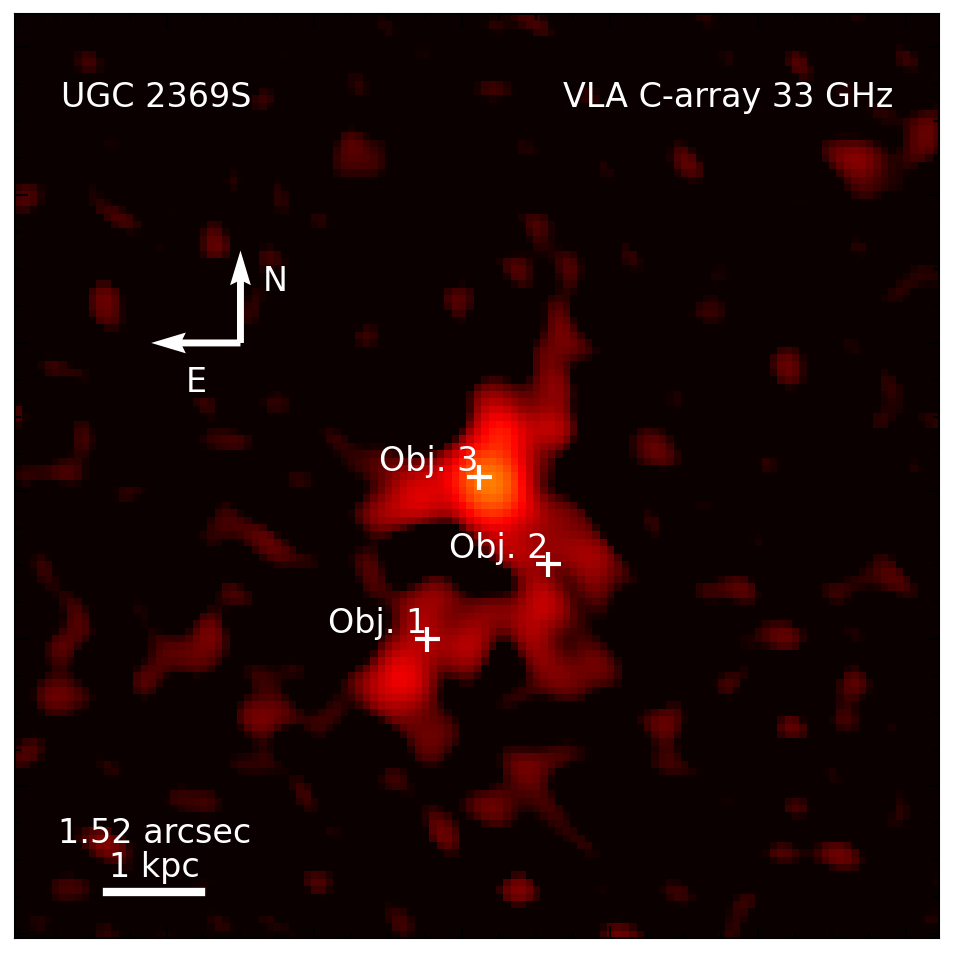

In [97]:
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":8,
"legend.fancybox":True})


imagecut=True
cutsize_arcsec=15 #arcsec
#KBSSpath="/disk/bifrost/yuanze/KBSS"
#cubename="Q0142"
#sourcename="BX186"
#redshift=2.3570
#hstpath=KBSSpath+"/"+cubename
#tag3 = "core3"
#sc3 = SkyCoord(RA[2], DEC[2], unit='deg',frame='icrs', equinox='J2000')
#tag2 = "core2"
#sc2 = SkyCoord(RA[1], DEC[1], unit='deg',frame='icrs', equinox='J2000')
tag1 = "core1"
sc = SkyCoord(RA[2], DEC[2], unit=u.deg,frame='icrs', equinox='J2000')
#dataname="na1e09010"
dataname="ugc02369_Ka_c_r0.5_ms.pbcor.image"

#ava=os.listdir(hstpath+"/hst/")
#ava=["q0100_f450w.fits","q0100_f555w.fits","q0100_f814w.fits","q0100_wfc3.fits"]
#for dataname in ava:
#hdu=fits.open(datapath+"/hst/"+dataname+"/"+dataname+"_drz.fits")
hdu=fits.open(datapath+"/VLA/"+dataname+".fits")
wcsall=WCS(hdu[0].header)
#print(hdu[0].header["INSTRUME"],hdu[0].header["DETECTOR"],hdu[0].header["FILTER"])

tant=wcsall.pixel_scale_matrix[0,1]/wcsall.pixel_scale_matrix[0,0]
xpix=1/np.sqrt(1+tant**2)*wcsall.pixel_scale_matrix[1,1]*3600
print(xpix)

pix_scale = xpix
#wcsall.pixel_scale_matrix[1, 1] * 3600  # scale in arcsec/pixel

# Calculate the size of the cutout in pixels
cutsize_pixels = cutsize_arcsec / pix_scale

# Create a cutout around the target coordinates
if imagecut:
 #   try:
    image = Cutout2D(hdu[0].data, sc, size=cutsize_pixels, wcs=wcsall)
    wcs=image.wcs
#    except:
#        print("source(s) not found")
#        continue
else:
    image=hdu[0].header
    wcs=wcsall
_, med, std = sigma_clipped_stats(image.data)
#wcs=new_wcs

norm = vis.ImageNormalize(vmin = std, vmax = med+1000*std,stretch=vis.stretch.LogStretch())

fig, ax = plt.subplots(figsize=(8,4),dpi=300)#subplot_kw={'projection': wcs}
ax.imshow(image.data,norm=norm,cmap="hot",origin="lower")
#if re.findall(r"606W.+",dataname):
    #ax.invert_xaxis()
#ax.set_title(dataname)


det_array=image.data.copy(order="C").byteswap().newbyteorder()

bkg=sep.Background(det_array)
bkg_image = bkg.back()
data_sub = det_array - bkg
objects = sep.extract(det_array, 3,minarea=100, err=std)
objects.sort(order=('y'))

rex=0.75/pix_scale
#plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
for i in range(len(objects[:3])):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=2*rex,#2*objects['a'][i],
                height=2*rex,#2*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi,ls="--")
    e.set_facecolor('none')
    e.set_edgecolor('white')
    e.set_linewidth(0.5)
    #ax.add_artist(e)
    #ax.text(objects['x'][i]*1.1,objects['y'][i]*1.1,"Object {:d}".format(i+1),horizontalalignment="center",va="center",color="white",fontsize=6)

#-------------------Reference scale setting----------------#
dT = 1  # kpc distance
delta_theta_deg = dT/Planck18.kpc_proper_per_arcmin(0.0318).value/60
delta_arcsec = delta_theta_deg*3600
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()
start_x = x_lim[0] + 0.10 * (x_lim[1] - x_lim[0])
start_y = y_lim[0] + 0.05 * (y_lim[1] - y_lim[0])
#start_coord = wcsall.pixel_to_world(start_x, start_y)
#end_coord = wcsall.pixel_to_world(start_x + 1, start_y)  # arbitrary +1 in pixel to get RA difference for 1 pixel

#delta_ra_per_pixel = start_coord.ra.degree - end_coord.ra.degree
delta_ra_per_pixel=pix_scale/3600
length_in_pixels = delta_theta_deg / delta_ra_per_pixel

ax.plot([start_x, start_x + length_in_pixels], [start_y, start_y], color='white', lw=2)
#ax.text(start_x + length_in_pixels / 2, start_y*1.2, '{} pc'.format(int(dT*1000)), color='white', ha='center', va='bottom')
ax.text(start_x + length_in_pixels / 2, start_y*1.2, '{} kpc'.format(dT), color='white', ha='center', va='bottom')
ax.text(start_x + length_in_pixels / 2, start_y*2, '{:.2f} arcsec'.format(delta_arcsec), color='white', ha='center', va='bottom')

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])

ax.text(0.05,0.9,"{} {}S".format(psname1,psname2),color="white",transform=ax.transAxes)
ax.text(0.95,0.9,"{} {}".format("VLA","C-array 33 GHz"),color="white",transform=ax.transAxes,horizontalalignment="right")
#ax.text(0.95,0.9,"{} {} {}".format(hdu[0].header["INSTRUME"]),color="white",transform=ax.transAxes,horizontalalignment="right")
#pixsc=wcs.world_to_pixel(sc)
#,hdu[0].header["DETECTOR"],hdu[0].header["FILTER"]
#ax.plot(pixsc[0],pixsc[1],"ro",markeredgewidth=.1,lw=0.01)
#plt.scatter(pixsc[0],pixsc[1], s=55, facecolors='none', edgecolors='r')
ms=5
lw=1




x0, y0 = 30,80
arrow_length = 1.5/3600

# Convert pixel coordinates to sky coordinates (RA, Dec)
sky_coords = wcs.pixel_to_world(x0, y0)
ra, dec = sky_coords.ra.deg, sky_coords.dec.deg

# Define the end points of the arrows in pixel coordinates
north_end = wcs.world_to_pixel_values(ra, dec + arrow_length)
east_end = wcs.world_to_pixel_values(ra + arrow_length, dec)


# Calculate the direction vectors for the arrows
north_vector = [north_end[0] - x0, north_end[1] - y0]
east_vector = [east_end[0] - x0, east_end[1] - y0]

# Plot the North arrow
ax.quiver(x0, y0, north_vector[0], north_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
ax.text(x0 + north_vector[0]/2+3, y0 + north_vector[1]/2, 'N', color='w', ha='left', va='bottom')

# Plot the East arrow
ax.quiver(x0, y0, east_vector[0], east_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
ax.text(x0 + east_vector[0]/2, y0 + east_vector[1]/2-3, 'E', color='w', ha='center', va='top')


for io in range(len(RA)):
    sc=SkyCoord(RA[io], DEC[io], unit='deg',frame='icrs', equinox='J2000')
    pixsc=wcs.world_to_pixel(sc)
    ax.plot(pixsc[0], pixsc[1],"+",c="w",ms=6,lw=0.1)
    ax.text(pixsc[0], pixsc[1],"Obj. {}".format(io+1),color="w",verticalalignment='bottom',horizontalalignment='right',fontsize=8)


#ax.plot(RA[0], DEC[0], transform=ax.get_transform('world'),color="green",marker="+", ms=ms,lw=lw)
#ax.text(RA[0], DEC[0],"{}-{}".format(psname1+psname2,tag1),color="green",transform=ax.get_transform('world'),verticalalignment='bottom',horizontalalignment='right')
#ax.plot(RA[1], DEC[1], transform=ax.get_transform('world'),color="green",marker="+", ms=ms,lw=lw)
#ax.text(RA[1], DEC[1],"{}-{}".format(psname1+psname2,tag2),color="green",transform=ax.get_transform('world'),verticalalignment='bottom',horizontalalignment='right')
#ax.plot(RA[2], DEC[2], transform=ax.get_transform('world'),color="green",marker="+", ms=ms,lw=lw)
#ax.text(RA[2], DEC[2],"{}-{}".format(psname1+psname2,tag3),color="green",transform=ax.get_transform('world'),verticalalignment='bottom',horizontalalignment='right')
#ax.scatter(sc3.ra.value, sc3.dec.value, transform=ax.get_transform('world'), s=55, edgecolor='r', facecolor='none')
#fig.savefig(datapath+"/fig/{}S_hst_nicmos.pdf".format(psname1+psname2))
fig.savefig(datapath+"/fig/{}S_vla_c.pdf".format(psname1+psname2))

#ax.text(sc3.ra.value, sc3.dec.value,"{}-{}".format(cubename,tag3),color="red",transform=ax.get_transform('world'),verticalalignment='bottom',horizontalalignment='right',fontsize=15)

## Align, reproject and calculate color

0.04999999999999968

In [168]:
import glob
from pathlib import Path
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":8,
"legend.fancybox":True})


imagecut=True
cutsize_arcsec=15 #arcsec

tag1 = "core1"
#sc = SkyCoord(RA[2], DEC[2], unit=u.deg,frame='icrs', equinox='J2000')
sc = SkyCoord(np.mean(RA[2]), np.mean(DEC[2]), unit=u.deg,frame='icrs', equinox='J2000')

image_to_align=["hst_10592_11_acs_wfc_f435w_j9cv11","hst_10592_11_acs_wfc_f814w_j9cv11","na1e09010"]
wcslist=[]
imagelist=[]
fluxlist=[]
for impre in image_to_align:
    fnames= glob.glob(datapath+"/hst/"+impre+"/"+impre+"*drc.fits")+glob.glob(datapath+"/hst/"+impre+"/"+impre+"*mos.fits")
    with fits.open(fnames[0]) as temphdu:
        if imagecut:
         #   try:
            pscale=WCS(temphdu[1].header).pixel_scale_matrix[1,1]*3600
            cutsize_pixels=cutsize_arcsec/pscale
            image = Cutout2D(temphdu[1].data, sc, size=cutsize_pixels, wcs=WCS(temphdu[1].header))
            wcs=image.wcs
        else:
            print("No cut image generated")
        wcslist.append(image.wcs)
        ABZP=np.nan
        try:
            invsens=temphdu[0].header["PHOTFLAM"]
            pwave=temphdu[0].header["PHOTPLAM"]
            ABZP=-2.5*np.log10(invsens)-5*np.log10(pwave)-21.10+18.6921
        except:
            invsens=temphdu[1].header["PHOTFLAM"]
            pwave=temphdu[1].header["PHOTPLAM"]
            ABZP=-2.5*np.log10(invsens)-5*np.log10(pwave)-21.10+18.6921
        imagelist.append(-2.5*np.log10(image.data)+ABZP)
        fluxlist.append(image.data*invsens*pwave) # monochromatic flux in erg/s/cm^2
        print("doing:",fnames[0])

doing: /disk/bifrost/yuanze/multiAGN/UGC2369/hst/hst_10592_11_acs_wfc_f435w_j9cv11/hst_10592_11_acs_wfc_f435w_j9cv11_drc.fits
doing: /disk/bifrost/yuanze/multiAGN/UGC2369/hst/hst_10592_11_acs_wfc_f814w_j9cv11/hst_10592_11_acs_wfc_f814w_j9cv11_drc.fits
doing: /disk/bifrost/yuanze/multiAGN/UGC2369/hst/na1e09010/na1e09010_mos.fits


/tmp/ipykernel_2084013/1334117844.py:43: RuntimeWarning: divide by zero encountered in log10
  imagelist.append(-2.5*np.log10(image.data)+ABZP)
/tmp/ipykernel_2084013/1334117844.py:43: RuntimeWarning: invalid value encountered in log10
  imagelist.append(-2.5*np.log10(image.data)+ABZP)


In [1865]:
ABZP

23.465406907308978

## Alignment

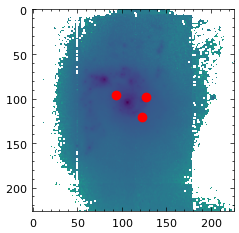

In [189]:
plt.imshow(imagelist[2])
plt.scatter(objects['x'][:3],objects['y'][:3],color="red")

In [196]:
sc = SkyCoord(np.mean(RA), np.mean(DEC), unit=u.deg,frame='icrs', equinox='J2000')
new_wcs.world_to_pixel(sc)

(array(114.08770121), array(105.26117326))

In [184]:
sources

array([(2., 633, 623, 35, 58, 47,  86, 41.33829399, 73.61558746, 37.79861799, 86.54619071, -26.28703381, 0., 0., 0., 9.90053272, 5.13071728, -1.15922332, 0.0335409 , 0.01464882,  0.02037503, 3681.55810547, 3686.16064453, 24.52450562, 26.05985832, 41, 74, 42, 74, 1),
       (2., 885, 876,  6, 56, 75, 108, 33.52123521, 83.6490209 , 88.09341199, 61.70335532,  18.29361804, 0., 0., 0., 9.87189007, 7.2348156 ,  0.47296166, 0.01209632, 0.01726982, -0.00717256, 5396.18896484, 5417.55810547, 57.08198929, 64.07766724, 33, 84, 32, 84, 1),
       (2., 849, 842,  6, 44, 47,  83, 28.73130182, 66.20869399, 79.93682862, 46.83639378, -19.30211494, 0., 0., 0., 9.42404461, 6.16121864, -0.4310022 , 0.01389235, 0.02371041,  0.01145057, 4665.12548828, 4673.12353516, 30.732481  , 33.222435  , 28, 66, 28, 66, 1)],
      dtype=[('thresh', '<f8'), ('npix', '<i8'), ('tnpix', '<i8'), ('xmin', '<i8'), ('xmax', '<i8'), ('ymin', '<i8'), ('ymax', '<i8'), ('x', '<f8'), ('y', '<f8'), ('x2', '<f8'), ('y2', '<f8'), ('xy'

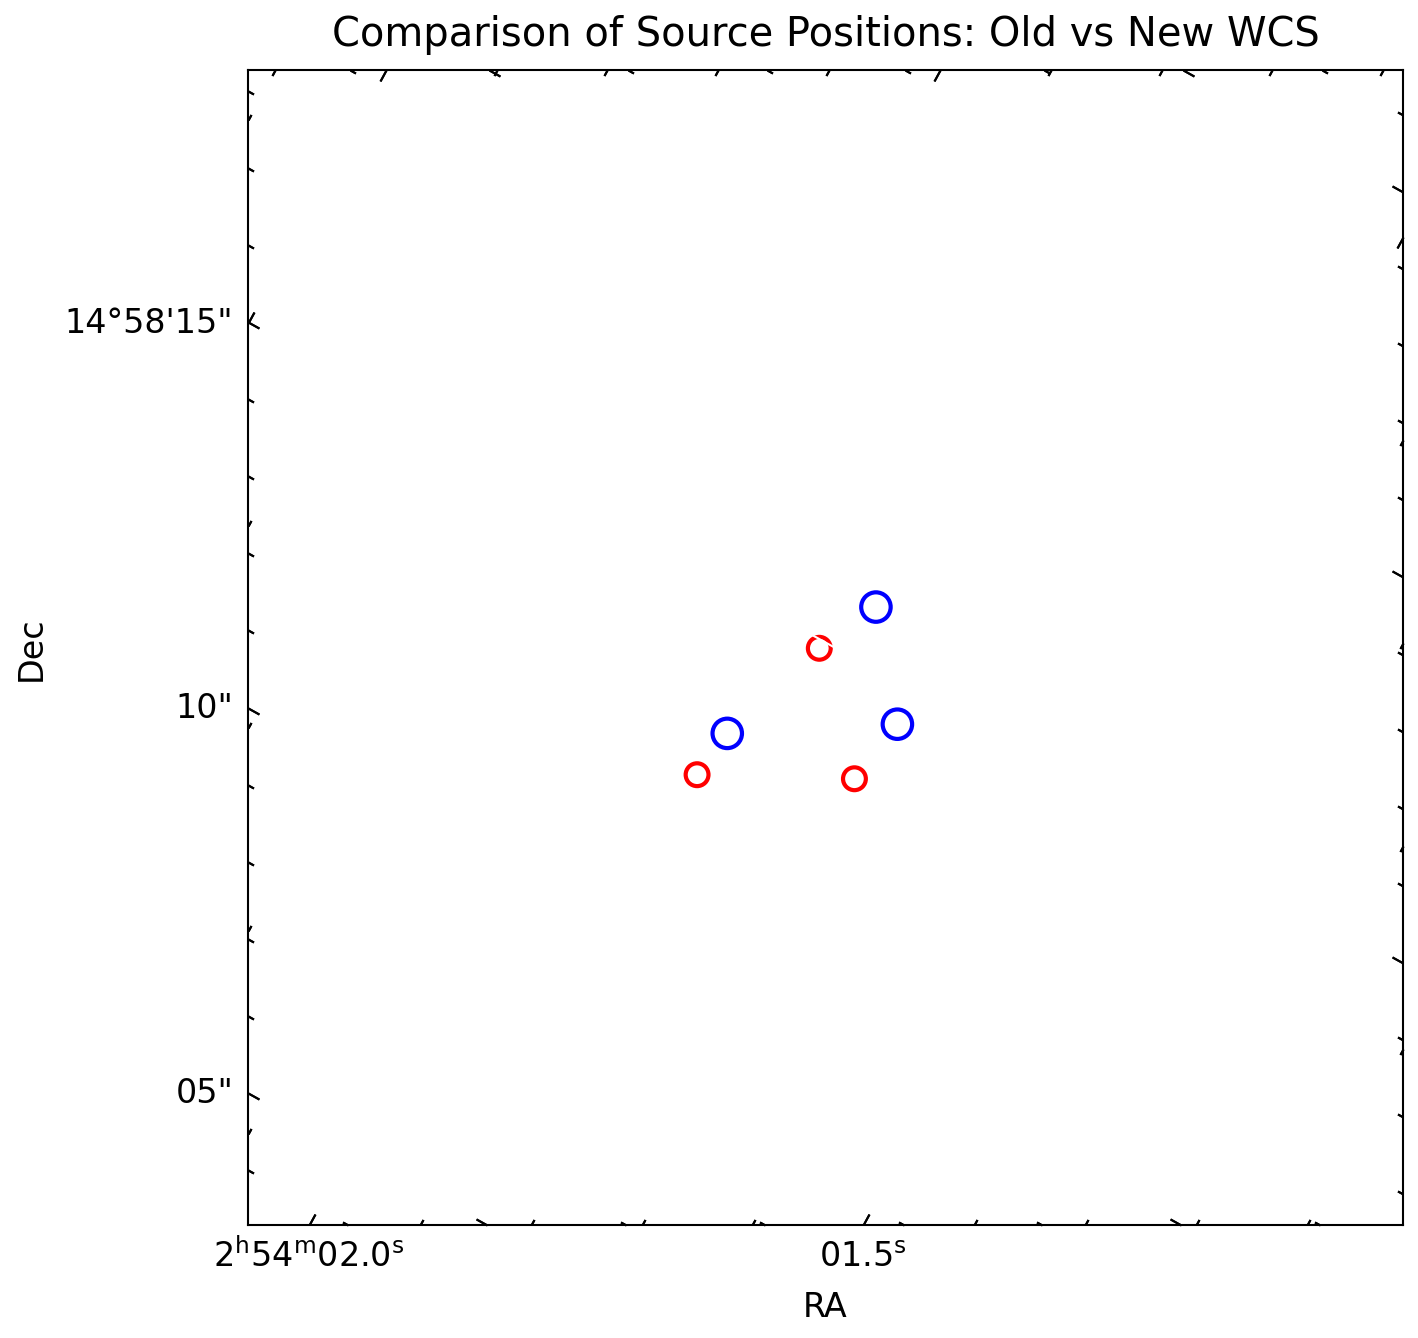

In [188]:
from astroquery.gaia import Gaia
from astroquery.sdss import SDSS
from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_sources,SourceCatalog,detect_threshold,deblend_sources
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.wcs.utils import fit_wcs_from_points

plt.style.use(["science","no-latex"])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":8,
"legend.fancybox":True})

wcslist_new=[]
# Identify sources in the image

#for tempind,data in enumerate(imagelist[-2:]):

## run WCS alignment on the Cutout image
## only the NICMOS image requires re-alignment
tempind=2
data=fluxlist[tempind]#image.data.copy(order="C").byteswap().newbyteorder()#imagelist[tempind]
old_wcs=wcslist[tempind]#image.wcs
mean, median, std = sigma_clipped_stats(data)
#daofind = DAOStarFinder(fwhm=4.0, threshold=10.*std)

bkg=sep.Background(data)
bkg_image = bkg.back()
data_sub = data - bkg
sources = objects#sep.extract(data, 3,minarea=100, err=std)#
#sources.sort(order=('y'))

#sources=stars
#sources = daofind(data - median)
#positions = np.transpose((sources['xcentroid'], sources['ycentroid']))

positions = np.transpose((sources['x'], sources['y']))
nsource=3
catalog = SkyCoord.from_pixel(sources["x"][:nsource], sources["y"][:nsource], wcs=old_wcs)

# Query Gaia or SDSS catalog
# For Gaia:
#Gaia.MAIN_GAIA_TABLE = "gaiaedr3.gaia_source"  # Specify the Gaia catalog version
#radius = 3 * u.arcsec  # Adjust as necessary
#center = catalog[0]  # Using the first source as the center, adjust as necessary

#result = Gaia.query_object_async(coordinate=center, radius=radius)
#gaia_coords = SkyCoord(result['ra'], result['dec'], unit='deg')

ref_coords = SkyCoord(ra=sentry["RA"].value,dec=sentry["Dec"].value,unit=u.deg)

# Cross-match sources
idx, d2d, _ = ref_coords.match_to_catalog_sky(catalog)
'''

# Query SDSS catalog
radius = 0.1 * u.deg  # Adjust as necessary
center = catalog[0]  # Using the first source as the center, adjust as necessary

query = SDSS.query_region(center, radius=radius, spectro=False, photoobj_fields=['ra', 'dec'])
sdss_coords = SkyCoord(query['ra'], query['dec'], unit='deg')

idx, d2d, _ = sdss_coords.match_to_catalog_sky(catalog)

'''

# Filter matches by a tolerance
tol = 2 * u.arcsec  # Adjust as necessary
matches = d2d < tol
matched_catalog = catalog[idx[matches]]
matched_ref = ref_coords[matches]

# Compute the WCS transformation
from astropy.wcs.utils import fit_wcs_from_points


matchedra=matched_ref.ra
matcheddec=matched_ref.dec
xp=positions[idx[matches]][:,0]
yp=positions[idx[matches]][:,1]


new_wcs = fit_wcs_from_points((xp,yp), SkyCoord(ra=matchedra,dec=matcheddec,unit=u.deg), projection=old_wcs)
wcslist_new.append(new_wcs)

#old_pixel_coords = np.transpose((sources['x'], sources['y']))
old_sky_coords = SkyCoord.from_pixel(positions[:nsource,0], positions[:nsource,1], wcs=old_wcs)

# Transform positions using new WCS
#new_sky_coords = SkyCoord.from_pixel(old_pixel_coords[:,0], old_pixel_coords[:,1], wcs=new_wcs)
new_sky_coords = SkyCoord(ra=matchedra,dec=matcheddec,unit=u.deg)
# Plot the positions
plt.figure(figsize=(5, 5),dpi=300)
plt.subplot(projection=old_wcs)

norm = vis.ImageNormalize(vmin = std, vmax = med+50*std,stretch=vis.stretch.LogStretch())

plt.imshow(data, origin='lower', cmap='gray_r', norm=norm)
plt.scatter(new_sky_coords.to_pixel(old_wcs)[0], new_sky_coords.to_pixel(old_wcs)[1], s=30, edgecolor='red', facecolor='none', label='Old WCS')
plt.scatter(new_sky_coords.to_pixel(new_wcs)[0], new_sky_coords.to_pixel(new_wcs)[1], s=50, edgecolor='blue', facecolor='none', label='New WCS')

#plt.scatter(s_coord.to_pixel(old_wcs)[0],s_coord.to_pixel(old_wcs)[1],s=50, edgecolor='g', facecolor='none', label='QSO')
#plt.scatter(191,401,s=50, edgecolor='m', facecolor='none', label='fitted_QSO')

#from regions import RectangleSkyRegion
#center = s_coord
#region_sky4 = RectangleSkyRegion(center=center,
#                                 width=30. * u.arcsec, height=30. * u.arcsec,
#                                 angle=0.0 * u.deg)
#region_pix4 = region_sky4.to_pixel(old_wcs)
#ax=plt.gca()
#region_pix4.plot(origin=(0, 0),ax=ax,color="orange")
#plt.legend()
plt.xlabel('RA')
plt.ylabel('Dec')
plt.title('Comparison of Source Positions: Old vs New WCS')
plt.grid(color='white', ls='solid')

# Save the updated header to the second image
#hdu2.header.update(new_wcs2.to_header())
#wcslist[tempind]=new_wcs

In [190]:
## update wcslist
wcslist[tempind]=new_wcs

In [198]:
wcslist[tempind],wcslist[1],wcslist[0]

(WCS Keywords
 
 Number of WCS axes: 2
 CTYPE : 'RA---TAN'  'DEC--TAN'  
 CRVAL : 43.50750000049003  14.970450000195997  
 CRPIX : 117.4272846658721  106.14795074636375  
 CD1_1 CD1_2  : -1.8061675719165503e-05  1.3476316963982631e-05  
 CD2_1 CD2_2  : 7.955432503895388e-06  1.8832002378522606e-05  
 NAXIS : 128  121,
 WCS Keywords
 
 Number of WCS axes: 2
 CTYPE : 'RA---TAN'  'DEC--TAN'  
 CRVAL : 43.51147315635306  14.975225996514968  
 CRPIX : -120.57850494604872  468.50160742464595  
 CD1_1 CD1_2  : -1.3888888888888e-05  8.470329472543e-22  
 CD2_1 CD2_2  : 8.470329472543e-22  1.38888888888888e-05  
 NAXIS : 300  300,
 WCS Keywords
 
 Number of WCS axes: 2
 CTYPE : 'RA---TAN'  'DEC--TAN'  
 CRVAL : 43.51147315635306  14.975225996514968  
 CRPIX : -120.57850494604872  468.50160742464595  
 CD1_1 CD1_2  : -1.3888888888888e-05  0.0  
 CD2_1 CD2_2  : 0.0  1.38888888888888e-05  
 NAXIS : 300  300)

## 2-color M/L ratio reconstruction 

In [162]:
from scipy.interpolate import RegularGridInterpolator
xgrid=np.linspace(0.6,4.1,80)
ygrid=np.linspace(2.7,-0.4,65)

xg, yg = np.meshgrid(xgrid, ygrid, indexing='ij', sparse=True)

H_matrix=np.genfromtxt(multiAGNpath+"/H_band_MoL_map.txt",delimiter=",")

MoL_map=RegularGridInterpolator((xgrid,ygrid),H_matrix.T,bounds_error=False,fill_value=np.nan)
#f(i-H,g-i)

In [1567]:
np.where(xgrid>3.30253165),np.where(ygrid>2.0)

((array([62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78,
         79]),),
 (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),))

In [1569]:
H_matrix[14,61]

0.37

In [199]:
MoL_map([2,0.2])

array([-1.03])

In [200]:
wcslist

[WCS Keywords
 
 Number of WCS axes: 2
 CTYPE : 'RA---TAN'  'DEC--TAN'  
 CRVAL : 43.51147315635306  14.975225996514968  
 CRPIX : -120.57850494604872  468.50160742464595  
 CD1_1 CD1_2  : -1.3888888888888e-05  0.0  
 CD2_1 CD2_2  : 0.0  1.38888888888888e-05  
 NAXIS : 300  300,
 WCS Keywords
 
 Number of WCS axes: 2
 CTYPE : 'RA---TAN'  'DEC--TAN'  
 CRVAL : 43.51147315635306  14.975225996514968  
 CRPIX : -120.57850494604872  468.50160742464595  
 CD1_1 CD1_2  : -1.3888888888888e-05  8.470329472543e-22  
 CD2_1 CD2_2  : 8.470329472543e-22  1.38888888888888e-05  
 NAXIS : 300  300,
 WCS Keywords
 
 Number of WCS axes: 2
 CTYPE : 'RA---TAN'  'DEC--TAN'  
 CRVAL : 43.50750000049003  14.970450000195997  
 CRPIX : 117.4272846658721  106.14795074636375  
 CD1_1 CD1_2  : -1.8061675719165503e-05  1.3476316963982631e-05  
 CD2_1 CD2_2  : 7.955432503895388e-06  1.8832002378522606e-05  
 NAXIS : 128  121]

NameError: name 'color_i_H' is not defined

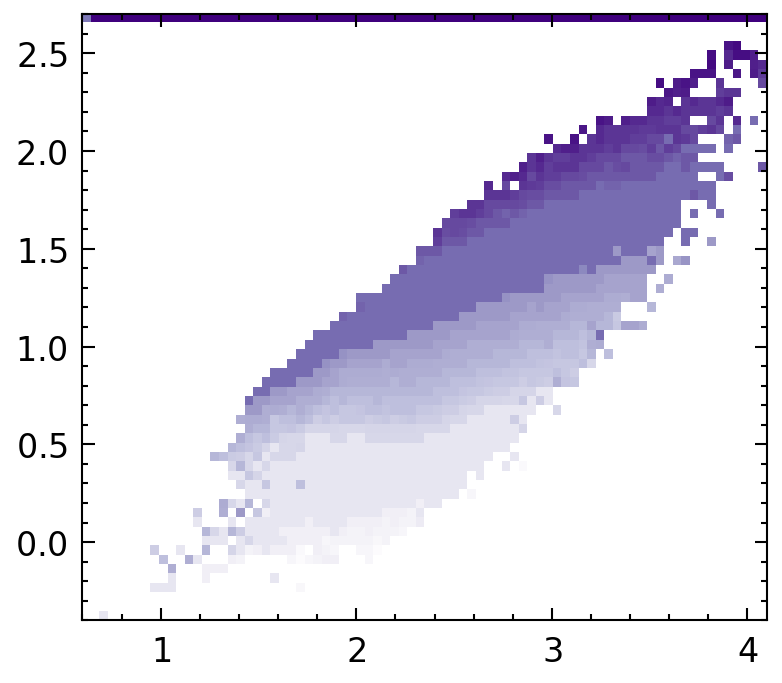

In [163]:
cmap = plt.cm.Purples
cmap.set_bad(color='none') 
fig=plt.figure(dpi=300)
ax=plt.gca()
im=plt.imshow(H_matrix, cmap=cmap,vmin=-1.4, vmax=0.8,extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()])
ax.hist2d( color_i_H.ravel(),color_g_i.ravel(),range=[[0.0, 4.2],[-0.5, 2.7]], bins=100, cmap='binary',cmin=10)

divider = make_axes_locatable(ax)
# Append axes to the right of ax, with 2% width and no padding
cax = divider.append_axes("right", size="5%", pad=0.0)
ax.scatter(3.30253165,2.11875,s=1)
# Create a colorbar in the new axes
cb=fig.colorbar(im, cax=cax)
cb.set_label(r"log(M/L)_H")


## Calculate g-i color 

In [192]:
from scipy.ndimage import map_coordinates
imagelist_repo=[imagelist[0]]
fluxlist_repo=[fluxlist[0]]
for ind,wcss in enumerate(wcslist[1:]):
    image_reprojected, footprint = reproject_interp((imagelist[ind+1], wcss), wcslist[0], shape_out=imagelist[0].shape)
    flux_reprojected, footprint = reproject_interp((fluxlist[ind+1], wcss), wcslist[0], shape_out=fluxlist[0].shape)
    imagelist_repo.append(image_reprojected)
    fluxlist_repo.append(flux_reprojected)
    print("reprojecting image No.",ind)
    #print(wcss.pixel_scale_matrix*3600)
    #print(imagelist[ind].shape)


color_g_i=imagelist_repo[0]-imagelist_repo[1]
color_i_H=imagelist_repo[1]-imagelist_repo[2]




reprojecting image No. 0
reprojecting image No. 1


In [211]:
## Using 2-color map (only available in limited parameter space)
shape=color_g_i.shape
logMoL_H=np.full(shape,np.nan)
for i in range(shape[0]):
    for j in range(shape[1]):
        logMoL_H[i,j]=MoL_map([color_i_H[i,j],color_g_i[i,j]])

/tmp/ipykernel_2084013/275034399.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  logMoL_H[i,j]=MoL_map([color_i_H[i,j],color_g_i[i,j]])


In [213]:
##using powerlaw approximation with g-i color
logMoL_H=-1.222+0.78*color_g_i


(array([[nan, nan, nan, ..., nan, nan,  2.],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 array([0.   , 0.042, 0.084, 0.126, 0.168, 0.21 , 0.252, 0.294, 0.336,
        0.378, 0.42 , 0.462, 0.504, 0.546, 0.588, 0.63 , 0.672, 0.714,
        0.756, 0.798, 0.84 , 0.882, 0.924, 0.966, 1.008, 1.05 , 1.092,
        1.134, 1.176, 1.218, 1.26 , 1.302, 1.344, 1.386, 1.428, 1.47 ,
        1.512, 1.554, 1.596, 1.638, 1.68 , 1.722, 1.764, 1.806, 1.848,
        1.89 , 1.932, 1.974, 2.016, 2.058, 2.1  , 2.142, 2.184, 2.226,
        2.268, 2.31 , 2.352, 2.394, 2.436, 2.478, 2.52 , 2.562, 2.604,
        2.646, 2.688, 2.73 , 2.772, 2.814, 2.856, 2.898, 2.94 , 2.982,
        3.024, 3.066, 3.108, 3.15 , 3.192, 3.234, 3.276, 3.318, 3.36 ,
        3.402, 3.444, 3.486, 3.528, 3.57 , 3.612, 3.654, 3.696, 3.738,
     

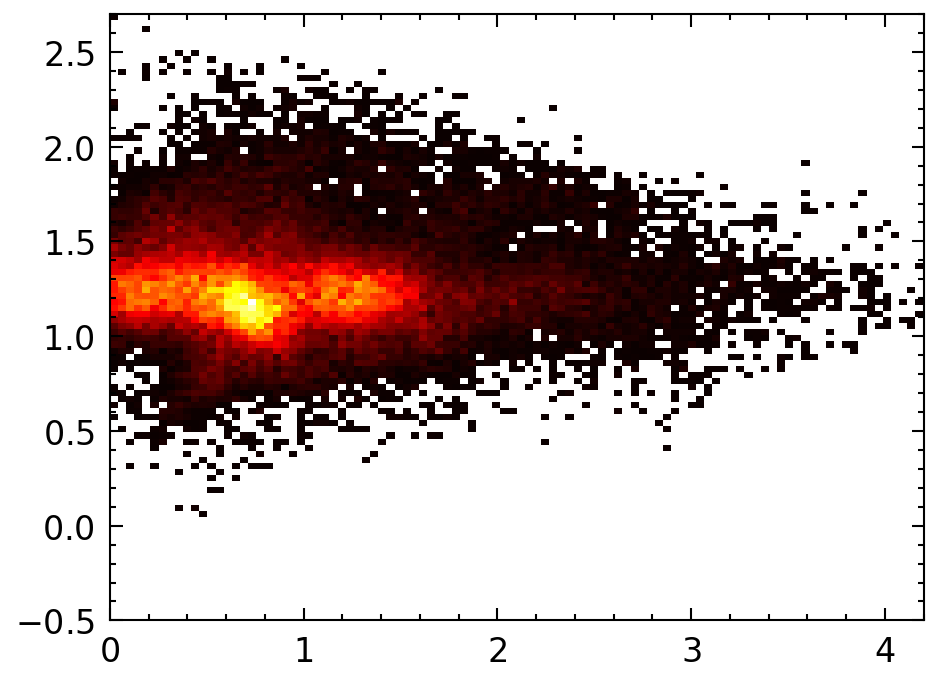

In [214]:
fig=plt.figure(dpi=300)
plt.hist2d( color_i_H.ravel(),color_g_i.ravel(),range=[[0.0, 4.2],[-0.5, 2.7]], bins=100, cmap='hot',cmin=2)

Text(0, 0.5, '$\\Delta$arcsec')

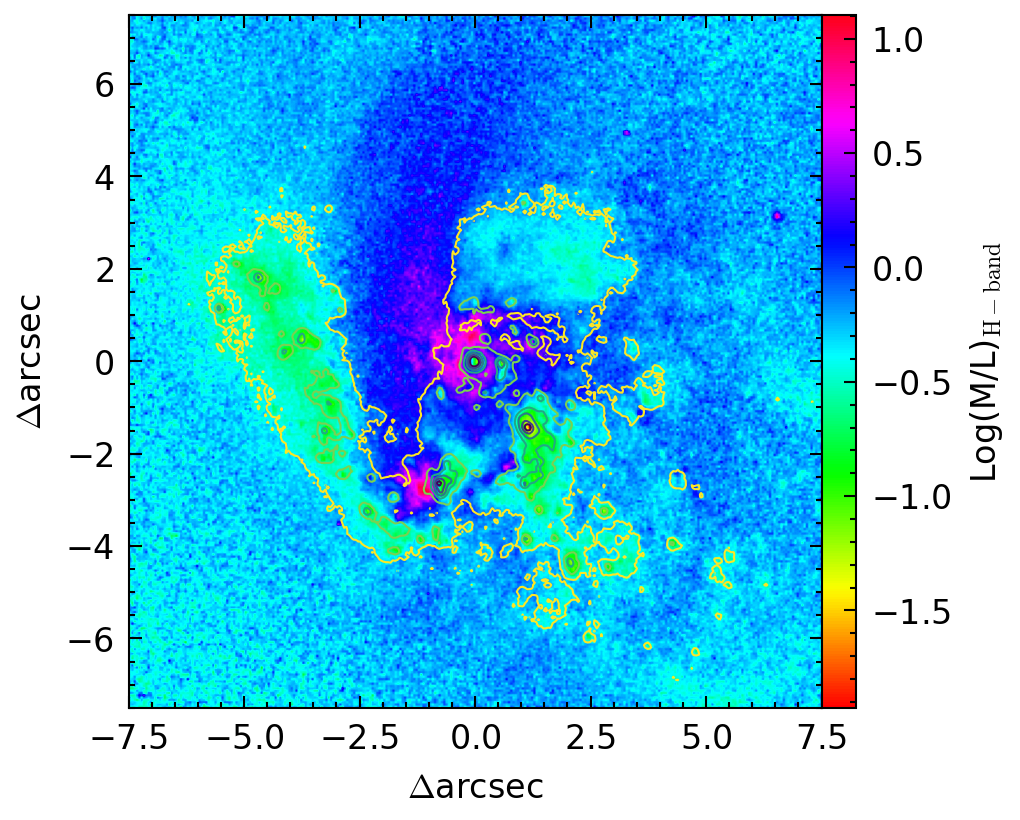

In [215]:
cutsize_arcsec=15#arcsec

wcs=wcslist[0]

sc = SkyCoord(np.mean(RA[2]), np.mean(DEC[2]), unit=u.deg,frame='icrs', equinox='J2000')

pix_scale=wcs.pixel_scale_matrix[1,1]*3600

cutsize_pixels = cutsize_arcsec / pix_scale
bflux=imagelist_repo[0]

image = logMoL_H#Cutout2D(logMoL_H, sc, size=cutsize_pixels, wcs=wcs)
bimage = bflux#Cutout2D(bflux, sc, size=cutsize_pixels, wcs=wcs)
#_, med, std = sigma_clipped_stats(image.data)
#_, bmed, bstd = sigma_clipped_stats(bimage.data)
bstd=np.nanstd(bimage)

norm = vis.ImageNormalize(vmin = np.nanmin(image), vmax = np.nanmax(image),stretch=vis.stretch.LinearStretch())
xmax=image.data.shape[1]
ymax=image.data.shape[0]
xscale=xmax/2
yscale=ymax/2


fig, ax = plt.subplots(figsize=(5,3),dpi=300)

Zm = np.ma.masked_where(bimage.data < 0.1*bstd, image.data)

im=ax.imshow(np.rot90(Zm.T),norm=norm,cmap="hsv",\
             extent=[-xmax*pix_scale/2, xmax*pix_scale/2, -ymax*pix_scale/2, ymax*pix_scale/2] )

for io in range(len(RA)):
    sc=SkyCoord(RA[io], DEC[io], unit='deg',frame='icrs', equinox='J2000')
    pixsc=wcs.world_to_pixel(sc)
    #ax.plot((pixsc[0]-xmax/2)*pix_scale, (pixsc[1]-ymax/2)*pix_scale,"+",c="w",ms=6,lw=0.1)
    #ax.text((pixsc[0]-xmax/2)*pix_scale, (pixsc[1]-ymax/2)*pix_scale,"Obj. {}".format(io+1),color="w",verticalalignment='bottom',horizontalalignment='right',fontsize=8)

    
    
contour_offset=2.0
levels = np.arange(  np.nanmin(bimage.data) + contour_offset,  28, 1.0 )
ax.contour(bimage.data,levels=levels,linewidths=0.5,\
             extent=[-xmax*pix_scale/2, xmax*pix_scale/2, -ymax*pix_scale/2, ymax*pix_scale/2] )

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
# Append axes to the right of ax, with 2% width and no padding
cax = divider.append_axes("right", size="5%", pad=0.0)

# Create a colorbar in the new axes
cb=fig.colorbar(im, cax=cax)
#cb.set_label(r"Velocity dispersion (km/s)")
cb.set_label(r"Log(M/L)$_\mathrm{H-band}$")
ax.set_xlabel(r"$\Delta$arcsec")
ax.set_ylabel(r"$\Delta$arcsec")

In [1871]:
np.nanmax(bimage.data)

inf

In [217]:
np.nanmax(bimage.data)-1

27.723960876464844

/tmp/ipykernel_2084013/2687222588.py:43: RuntimeWarning: invalid value encountered in log10
  Zm = np.log10(np.ma.masked_where(bimage.data < 2*bstd, 10**image.data/constants.L_sun.to(u.erg/u.s).value*L_H.data))


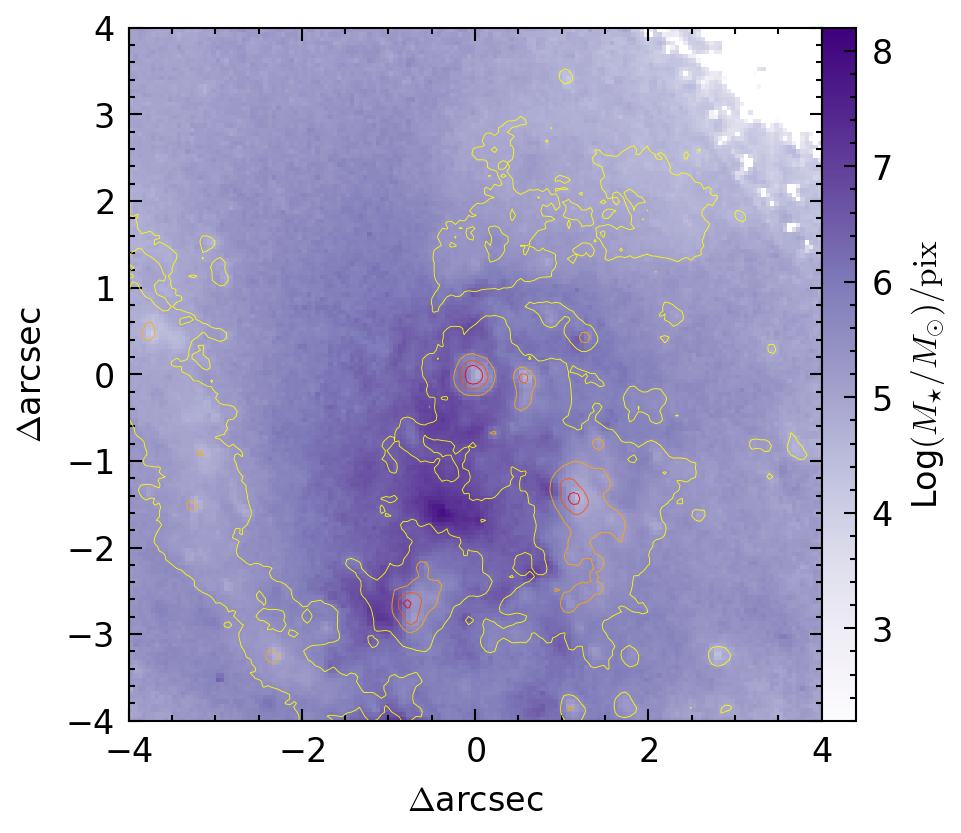

In [219]:
plt.rcdefaults()
plt.style.use(["science","no-latex"])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":8,
"legend.fancybox":True})
cutsize_arcsec=8#arcsec

wcs=wcslist[0]

sc = SkyCoord(np.mean(RA[2]), np.mean(DEC[2]), unit=u.deg,frame='icrs', equinox='J2000')

pix_scale=wcs.pixel_scale_matrix[1,1]*3600

kpc_per_arcsec=Planck18.kpc_proper_per_arcmin(0.032).value/60

cutsize_pixels = cutsize_arcsec / pix_scale
bflux=imagelist_repo[0]
bimage = Cutout2D(bflux, sc, size=cutsize_pixels, wcs=wcs)

Hflux=fluxlist_repo[2]

#_, med, std = sigma_clipped_stats(Hflux)
ld=Planck18.luminosity_distance(0.0312).to(u.cm)

Himage = Cutout2D(Hflux*4*np.pi*ld.value**2, sc, size=cutsize_pixels, wcs=wcs)

L_H = Himage
#m_st2 = -2.5 * np.log10(bimage.data*)
#gamma_sun=5133*u.kg.to(u.g)*u.W.to(u.erg/u.s)

image = Cutout2D(logMoL_H, sc, size=cutsize_pixels, wcs=wcs)

_, bmed, bstd = sigma_clipped_stats(bimage.data)


xmax=image.data.shape[1]
ymax=image.data.shape[0]
fig, ax = plt.subplots(figsize=(5,3),dpi=300)

#/(pix_scale*kpc_per_arcsec)**2)
Zm = np.log10(np.ma.masked_where(bimage.data < 2*bstd, 10**image.data/constants.L_sun.to(u.erg/u.s).value*L_H.data))
#Zm = np.log10(np.ma.masked_where(bin_indices!=1, 10**image.data*m_st/pix_scale**2))

norm = vis.ImageNormalize(vmin = 2.2,vmax=8.2,stretch=vis.stretch.LinearStretch())
#np.nanmin(Zm), vmax =np.nanmax(Zm)


im=ax.imshow(Zm,norm=norm,cmap="Purples",origin="lower",\
             extent=[-xmax*pix_scale/2, xmax*pix_scale/2, -ymax*pix_scale/2, ymax*pix_scale/2] )


contour_offset=2.0
levels = np.arange(  np.nanmin(bimage.data) + contour_offset,  np.nanmax(bimage.data)-1, 1.5 )

ax.contour(bimage.data,levels=levels,linewidths=0.2,cmap="autumn",#origin="lower",\
             extent=[-xmax*pix_scale/2, xmax*pix_scale/2, -ymax*pix_scale/2, ymax*pix_scale/2] )
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
# Append axes to the right of ax, with 2% width and no padding
cax = divider.append_axes("right", size="5%", pad=0.0)

# Create a colorbar in the new axes
cb=fig.colorbar(im, cax=cax)
obj3=np.array([0,0])
obj2=np.array([1.2,-1.4])
obj1=np.array([-0.75,-2.6])
#ax.scatter(obj1[0],obj1[1],marker="+",color="red",label="obj1")
#ax.scatter(obj2[0],obj2[1],marker="+",color="red",label="obj2")
#ax.scatter(obj3[0],obj3[1],marker="+",color="red",label="obj3")

#cb.set_label(r"Velocity dispersion (km/s)")
cb.set_label(r"Log$(M_{\star}/M_{\odot})\rm /pix$")
ax.set_xlabel(r"$\Delta$arcsec")
ax.set_ylabel(r"$\Delta$arcsec")
fig.savefig(datapath+"/fig/HST_Mstar.pdf")

In [2006]:
np.nanmax(bimage.data)

29.125927

In [599]:
Zm.mean()

5.204972728531726

In [1994]:
xmax=image.data.shape[1]
ymax=image.data.shape[0]
print(pix_scale)
xmin,xmax=-xmax*pix_scale/2, xmax*pix_scale/2
ymin,ymax=-ymax*pix_scale/2, ymax*pix_scale/2

0.04999999999999968


0.04999999999999968

In [210]:
def circularly_averaged_radial_distribution(stellar_mass_map,center, num_bins,rmax,Mstar=True,mag=False):
    # Determine the center of the 2D map
    #center = np.array(stellar_mass_map.shape) // 2
    total_in_rmax=0
    # Create coordinate grids
    y, x = np.indices(stellar_mass_map.shape)
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    #r=np.rot90(r.T)
    # Define the bins
    r_max = rmax
    bins = np.linspace(0, r_max, num_bins + 1)
    
    # Digitize the radial distances into bins
    bin_indices = np.digitize(r, bins) - 1
    #print(r)
    #print(bin_indices)
    fig=plt.figure(dpi=300)
    im=plt.imshow(bin_indices,origin="lower")
    ax=plt.gca()
    divider = make_axes_locatable(ax)
    # Append axes to the right of ax, with 2% width and no padding
    cax = divider.append_axes("right", size="5%", pad=0.0)
    cb=fig.colorbar(im, cax=cax)
    # Calculate the circularly averaged stellar mass in each bin
    radial_distribution = np.zeros(num_bins)
    for i in range(num_bins):
        total_in_rmax+=np.nansum(10**stellar_mass_map[bin_indices == i])
        if Mstar:
            radial_distribution[i] = (10**stellar_mass_map[bin_indices == i]).mean()
        elif mag:
            radial_distribution[i] = np.nanmean(10**(stellar_mass_map[bin_indices == i]/-2.5))
        else:
            raise("Error: invalid switches")
    
    return bins[1:], radial_distribution,bin_indices, total_in_rmax

# Example usage
stellar_mass_map = Zm  # Replace with your actual stellar mass map
num_bins = 30  # Number of radial bins
num_of_pix = 30 #radius of circle (pix)
obj3=np.array([0,0])
obj2=np.array([1.2,-1.4])
obj1=np.array([-0.75,-2.6])
#obj=objects['x']*pix_scale]
center=(obj3-np.array([ymin,xmin]))/pix_scale
#center=(np.array([-0.9,-1.25])-np.array([ymin,xmin]))/pix_scale
radii, radial_distribution,bin_indices,Mtotal = circularly_averaged_radial_distribution(stellar_mass_map, center,num_bins,num_of_pix,Mstar=True,mag=False)#wcs.pixel_scale_matrix[1,1]*3600)
print("total mass %.2e"%Mtotal)
print("radius of circle:",pix_scale*num_of_pix)

NameError: name 'ymin' is not defined

Text(0, 0.5, 'Stellar mass surface density (M/Msun/kpc)')

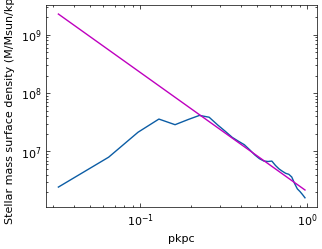

In [2271]:
import scipy
arcsec2kpc=Planck18.kpc_proper_per_arcmin(0.0312).value/60

plt.plot(radii*pix_scale*arcsec2kpc,radial_distribution)
plt.yscale("log")
plt.xscale("log")
res=scipy.stats.linregress(np.log10(radii[5:]*pix_scale*arcsec2kpc),np.log10(radial_distribution[5:]))

plt.plot(radii*pix_scale*arcsec2kpc,10**(res.intercept+res.slope*np.log10(radii*pix_scale*arcsec2kpc)),"m")

plt.xlabel("pkpc")
plt.ylabel("Stellar mass surface density (M/Msun/kpc)")

In [2266]:
res

LinregressResult(slope=-2.058769768113424, intercept=5.726910109326002, rvalue=-0.9770210422617417, pvalue=6.096190441201048e-17, stderr=0.09365064137229748, intercept_stderr=0.032030049910431804)

In [2176]:
dydx = np.gradient(np.cumsum(radial_distribution), np.diff(radii*pix_scale*arcsec2kpc)[0])

In [2177]:
dydx,radii*pix_scale*arcsec2kpc

(array([1.77523322e+10, 2.38750123e+10, 4.47054447e+10, 5.05752504e+10,
        3.74744887e+10, 3.22036667e+10, 2.79832578e+10, 2.33488355e+10,
        2.26997823e+10, 2.15364454e+10, 1.86631135e+10, 1.70590669e+10,
        1.39807994e+10, 1.05144683e+10, 9.08222833e+09, 8.27534790e+09,
        7.29736740e+09, 6.66963706e+09, 6.33650555e+09, 6.17539184e+09,
        6.38067995e+09, 6.79590668e+09, 7.57191652e+09, 9.07533913e+09,
        9.88834786e+09, 1.01010364e+10, 1.16795671e+10, 1.35757988e+10,
        1.44292570e+10, 1.45354377e+10]),
 array([0.        , 0.0645182 , 0.12903641, 0.19355461, 0.25807281,
        0.32259101, 0.38710922, 0.45162742, 0.51614562, 0.58066382,
        0.64518203, 0.70970023, 0.77421843, 0.83873664, 0.90325484,
        0.96777304, 1.03229124, 1.09680945, 1.16132765, 1.22584585,
        1.29036405, 1.35488226, 1.41940046, 1.48391866, 1.54843687,
        1.61295507, 1.67747327, 1.74199147, 1.80650968, 1.87102788]))

In [361]:
pcigale="/disk/bifrost/yuanze/cigale-v2022.1/database_builder"
nicmosf160=np.genfromtxt(pcigale+"/filters/gazpar/hst/nicmos/F160W.pb")
ACSf435=np.genfromtxt(pcigale+"/filters/gazpar/hst/wfc/F435W.pb")
ACSf814=np.genfromtxt(pcigale+"/filters/gazpar/hst/wfc/F814W.pb")


ukirtH=np.genfromtxt(pcigale+"/filters/gazpar/ukirt/H.pb")



sdssg=np.genfromtxt(pcigale+"/filters/gazpar/sdss/gp.pb")
sdssu=np.genfromtxt(pcigale+"/filters/gazpar/sdss/up.pb")
sdssi=np.genfromtxt(pcigale+"/filters/gazpar/sdss/ip.pb")

In [1199]:
ld

NameError: name 'ld' is not defined

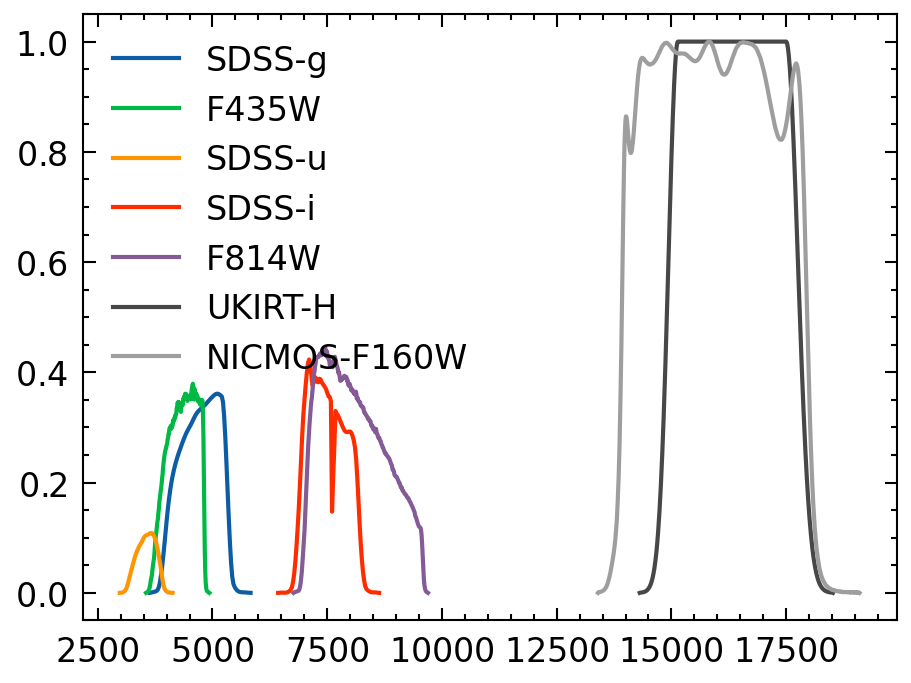

In [363]:
fig=plt.figure(dpi=300)
plt.plot(sdssg[:,0],sdssg[:,1],label="SDSS-g")
plt.plot(ACSf435[:,0],ACSf435[:,1],label="F435W")
plt.plot(sdssu[:,0],sdssu[:,1],label="SDSS-u")

plt.plot(sdssi[:,0],sdssi[:,1],label="SDSS-i")
plt.plot(ACSf814[:,0],ACSf814[:,1],label="F814W")

plt.plot(ukirtH[:,0],ukirtH[:,1],label="UKIRT-H")
plt.plot(nicmosf160[:,0],nicmosf160[:,1],label="NICMOS-F160W")

plt.legend()

In [2155]:
Omega13=dv1v3/aout/u.kpc
Omega23=dv2v3/ain/u.kpc
Omega13.to(1/u.s),Omega23.to(1/u.s)

(<Quantity 2.1388252e-15 1 / s>, <Quantity 8.11403806e-16 1 / s>)

In [2193]:
v1-v3

<Quantity 116155.15962074 m / s>

In [2150]:
ain=1.16
aout=1.76
m1=1.56e8
m2=3.94e7
m3=3.68e8


v1,v2,v3=constants.c*((1+np.array(sentry["z_sys"]))**2-1)/((1+np.array(sentry["z_sys"]))**2+1)
dv2v3=np.abs(v2-v3)
dv1v3=np.abs(v1-v3)


ms1=6.5e9
ms2=4.8e9
ms3=2.32e10
sigma3=208
sigma2=125
sigma1=171
eout=0.12
qout=(m1+ms1)/(m2+ms2+m3+ms3)
2.8*ain*((1+qout)*(1+eout)/np.sqrt(1-eout))**2/5

1.4107318405395115

In [2197]:
(np.sqrt(((constants.G*(ms3+m3+m1+ms1)*constants.M_sun)/(aout*u.kpc)**3).decompose())*aout*u.kpc).to(u.km/u.s)

<Quantity 271.76916547 km / s>

In [2070]:
t23=2.7/6*ain/30*(sigma3/200)**2*(100/sigma2)**3*1000
t13=2.7/6*aout/30*(sigma3/200)**2*(100/sigma1)**3*1000
print("Chandrasekhar DF timescale (Myr):",t23,t13)

Chandrasekhar DF timescale (Myr): 9.635758080000004 5.710607012384076


In [2072]:
19/6*(ain/5)**2*sigma3/200*1e8/ms2*1000

3.692924444444444

In [2164]:
(Omega13**2*(aout*u.kpc)**3/(constants.G*(ms3+m3)*constants.M_sun)).decompose()

<Quantity 0.23426417>

In [2182]:
q23=(m2+ms2)/(ms3+m3)
q13=(ms1+m1)/(ms3+m3)
rt2=(q23/(2+(Omega23**2*(ain*u.kpc)**3/(constants.G*(ms3+m3)*constants.M_sun)).decompose()-ain/(ms3+m3)*6.6e9))**1/3*ain
rt1=(q13/(2+(Omega13**2*(aout*u.kpc)**3/(constants.G*(ms3+m3)*constants.M_sun)).decompose()-aout/(ms3+m3)*1.4e10))**1/3*aout
print(rt2/arcsec2kpc)

0.073042126957174


In [963]:

rjcube=constants.G*(m2+ms2)*u.Msun*(ain*u.kpc)**2/4/(sigma3*u.km/u.s)**2

In [964]:
(rjcube.to(u.kpc**3).value)**1/3

0.0006320511271773268

In [976]:
sigc=constants.G*(m1+m3+m2)*u.Msun/(aout*u.kpc)

In [977]:
np.sqrt(sigc.to((u.km/u.s)**2))

<Quantity 37.10501674 km / s>

## Figure for KCWI proposal

In [1099]:
#Planck18.kpc_proper_per_arcmin(redshift).value/60
wcsall.world_to_pixel(sc)

(array(2185.70319321), array(3185.16446689))

In [20]:
DEC

[14.9700775, 14.97041556, 14.9708075]

dir exists


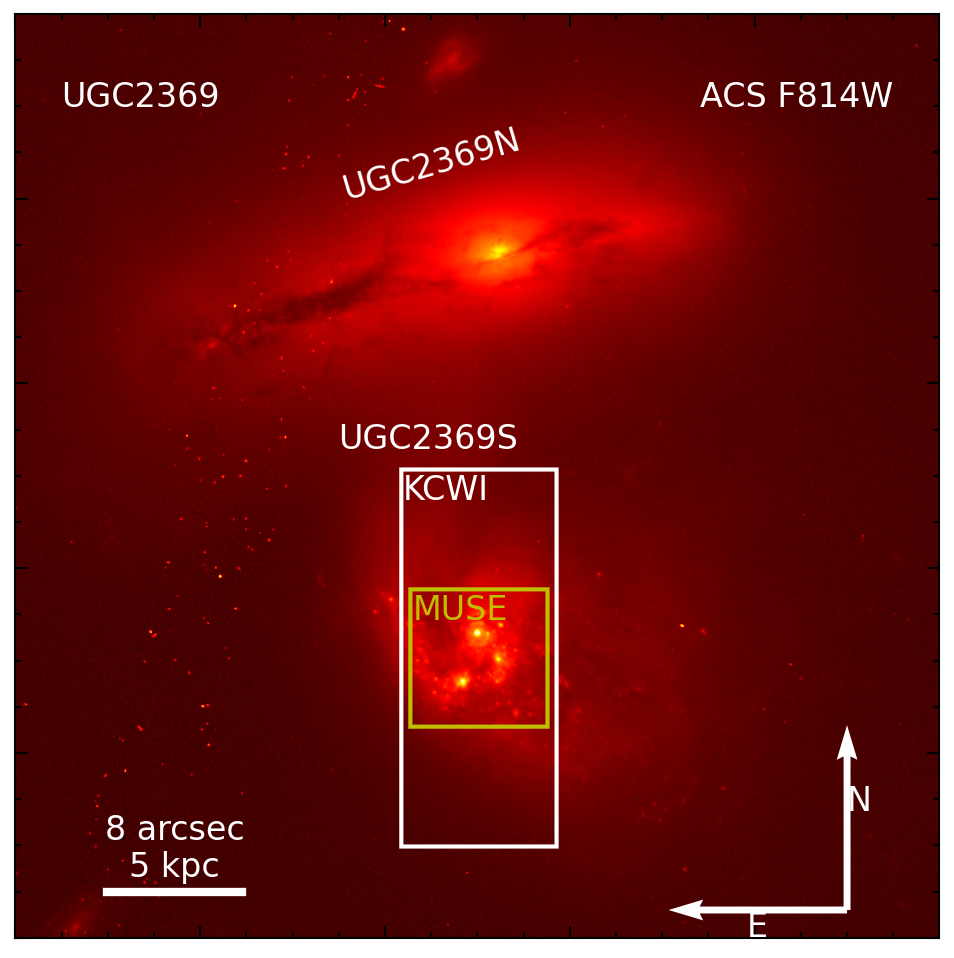

In [58]:
# Making inset for zoom-in figure
plt.style.use(["science",'no-latex'])
plt.rcParams.update({
    "font.family": "dejavu sans",   # specify font family here
    "font.serif": ["Times"],  # specify font here
    "font.size":8,
"legend.fancybox":True})


imagecut=True
cutsize_arcsec0=50 #ny,arcsec
cutsize_arcsec1=50 #nx
cutsize_arcsec2=10
sc3 = SkyCoord(RA[2], (DEC[2]+8.5/3600), unit=(u.deg,u.deg),frame='icrs', equinox='J2000')

sc2 = SkyCoord(RA[1], DEC[1], unit=(u.deg,u.deg),frame='icrs', equinox='J2000')
tag1 = "core1"
#sc = SkyCoord(RA[2], DEC[2], unit=(u.deg,u.deg),frame='icrs', equinox='J2000')
sc = SkyCoord(np.mean(RA), np.mean(DEC), unit=(u.deg,u.deg),frame='icrs', equinox='J2000')
#sc = SkyCoord(198.82194, 44.40711, unit=(u.deg,u.deg),frame='icrs', equinox='J2000')

dataname="ugc2369i"

hdu=fits.open(datapath+"/hst/"+dataname+"/"+dataname.lower()+".fits")
wcsall=WCS(hdu[1].header)
#print(hdu[0].header["DETECTOR"],hdu[0].header["FILTER"])
pix_scale = np.abs(wcsall.pixel_scale_matrix[1, 1]) * 3600  # scale in arcsec/pixel

# Calculate the size of the cutout in pixels
cutsize_pixels0 = cutsize_arcsec0 / pix_scale
cutsize_pixels1= cutsize_arcsec1 / pix_scale

# Create a cutout around the target coordinates
image0 = Cutout2D(hdu[1].data, sc3, size=[cutsize_pixels0,cutsize_pixels1], wcs=wcsall)
wcs0=image0.wcs
_, med, std = sigma_clipped_stats(image0.data)
wcsall=wcs0

norm = vis.ImageNormalize(vmin = std, vmax = med+2000*std,stretch=vis.stretch.LogStretch())

fig, ax = plt.subplots(figsize=(4,4),dpi=300)
ax.imshow(image0.data,norm=norm,cmap="hot")
ax.invert_yaxis()

#-------------------Reference scale setting----------------#
dT = 5  # kpc distance
delta_theta_deg = dT/Planck18.kpc_proper_per_arcmin(redshift).value/60
delta_arcsec = delta_theta_deg*3600
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()
start_x = x_lim[0] + 0.10 * (x_lim[1] - x_lim[0])
start_y = y_lim[0] + 0.05 * (y_lim[1] - y_lim[0])
start_coord = wcs0.pixel_to_world(start_x, start_y)
end_coord = wcs0.pixel_to_world(start_x + 1, start_y)  # arbitrary +1 in pixel to get RA difference for 1 pixel

delta_ra_per_pixel = start_coord.ra.degree - end_coord.ra.degree
length_in_pixels = np.abs(delta_theta_deg / delta_ra_per_pixel)

ax.plot([start_x, start_x + length_in_pixels], [start_y, start_y], color='white', lw=2)
#ax.text(start_x + length_in_pixels / 2, start_y*1.2, '{} pc'.format(int(dT*1000)), color='white', ha='center', va='bottom')
ax.text(start_x + length_in_pixels / 2, start_y*1.2, '{} kpc'.format(dT), color='white', ha='center', va='bottom')
ax.text(start_x + length_in_pixels / 2, start_y*2.0, '{:.0f} arcsec'.format(delta_arcsec), color='white', ha='center', va='bottom')
ax.text(0.95,0.9,"{} {}".format(hdu[0].header["INSTRUME"],hdu[0].header["FILTER"]),color="white",transform=ax.transAxes,horizontalalignment="right")


#-------------------inset setup-----------------------#
"""
axins=ax.inset_axes([1.1,0.25,0.5,0.5])

center_pixel = wcs0.world_to_pixel(sc2)
arcsec_per_pixel = wcs0.pixel_scale_matrix[1,1]*3600
pixels_per_narcsec = cutsize_arcsec2 / arcsec_per_pixel
axins.imshow(image0.data,norm=norm,cmap="hot")
axins.set_xlim(center_pixel[0] - pixels_per_narcsec, center_pixel[0] + pixels_per_narcsec)
axins.set_ylim(center_pixel[1] - pixels_per_narcsec, center_pixel[1] + pixels_per_narcsec)
axins.set_yticklabels([])
axins.set_xticklabels([])
#axins.set_xlabel("Energy (keV)",fontsize=10)
#axins.legend(prolines,labels,loc='lower right',bbox_to_anchor=[1.0, 0.6],markerfirst=False)
rec,clines=ax.indicate_inset_zoom(axins,edgecolor="y",ls=':')
#clines[0].set_linestyle(':')
#clines[1].set_linestyle(':')
axins.text(0.05,0.9,"{}".format(psname1+psname2+"NED02"),color="white",transform=axins.transAxes)
"""

from regions import RectangleSkyRegion
region_sky3 = RectangleSkyRegion(center=sc,
                                 width=7.42 * u.arcsec, height=7.43 * u.arcsec,
                                 angle=0.0 * u.deg)
region_pix3 = region_sky3.to_pixel(wcs0)
region_pix3.plot(origin=(0, 0),ax=ax,color="y")

region_sky4 = RectangleSkyRegion(center=sc,
                                 width=8.4 * u.arcsec, height=20.4 * u.arcsec,
                                 angle=0.0 * u.deg)
region_pix4 = region_sky4.to_pixel(wcs0)
region_pix4.plot(origin=(0, 0),ax=ax,color="w")

#ax.invert_xaxis()
x0, y0 = 900, 30
arrow_length = 10/3600

# Convert pixel coordinates to sky coordinates (RA, Dec)
sky_coords = wcsall.pixel_to_world(x0, y0)
ra, dec = sky_coords.ra.deg, sky_coords.dec.deg

# Define the end points of the arrows in pixel coordinates
north_end = wcsall.world_to_pixel_values(ra, dec + arrow_length)
east_end = wcsall.world_to_pixel_values(ra + arrow_length, dec)


# Calculate the direction vectors for the arrows
north_vector = [north_end[0] - x0, north_end[1] - y0]
east_vector = [east_end[0] - x0, east_end[1] - y0]
# Plot the North arrow
ax.quiver(x0, y0, north_vector[0], north_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
ax.text(x0 + north_vector[0]/2, y0 + north_vector[1]/2, 'N', color='w', ha='left', va='bottom')

# Plot the East arrow
ax.quiver(x0, y0, east_vector[0], east_vector[1], angles='xy', scale_units='xy', scale=1, color='w')
ax.text(x0 + east_vector[0]/2, y0 + east_vector[1]/2, 'E', color='w', ha='center', va='top')
ax.text(0.05,0.9,"{}".format(psname1+psname2),color="white",transform=ax.transAxes)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_xlabel("")
ax.set_ylabel("")

ax.text(0.35,0.8,"UGC2369N",rotation=16.3,color="white",transform=ax.transAxes)
ax.text(0.35,0.53,"{}".format(psname1+psname2+"S"),rotation=0,color="white",transform=ax.transAxes)
ax.text(0.42,0.475,"KCWI",rotation=0,color="white",transform=ax.transAxes)
ax.text(0.43,0.345,"MUSE",rotation=0,color="y",transform=ax.transAxes)

try:
    os.mkdir(datapath+"/fig")
except:
    print("dir exists")
fig.savefig(datapath+"/fig/{}_overview.pdf".format(psname1+psname2))

In [17]:
hdu[0].data

## Reading voronoi binned PyQSOFit results

In [195]:
line_priors = np.rec.array([
    (6564.61, 'Ha', 6400, 6800, 'Ha',   1, 0.0, 0.0, 1e10, 1e-3, 1.e-5, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (6549.85, 'Ha', 6400, 6800, 'NII6549', 1, 0.0, 0.0, 1e10, 1e-3, 1.e-5, 0.00169, 5e-3, 1, 1, 1, 0.001, 1),
    (6585.28, 'Ha', 6400, 6800, 'NII6585', 1, 0.0, 0.0, 1e10, 1e-3, 1.e-5, 0.00169, 5e-3, 1, 1, 1, 0.003, 1),
    (6718.29, 'Ha', 6400, 6800, 'SII6718', 1, 0.0, 0.0, 1e10, 1e-3, 1.e-5, 0.00169, 5e-3, 1, 1, 2, 0.001, 1),
    (6732.67, 'Ha', 6400, 6800, 'SII6732', 1, 0.0, 0.0, 1e10, 1e-3, 1.e-5, 0.00169, 5e-3, 1, 1, 2, 0.001, 1),
#FWHM = 2.355*2.3e-4*c0.
#    (4862.68, 'Hb', 4640, 5100, 'Hb_br', 2, 0.0, 0.0, 1e10, 5e-3,  4e-4,  0.05,        0.01, 0, 0, 0, 0.01, 1),
    (4862.68, 'Hb', 4640, 5100, 'Hb', 1, 0.0, 0.0, 1e10, 1e-3, 1.e-5, 0.00169,     0.01, 1, 1, 0, 0.002, 1),
    (4960.30, 'Hb', 4640, 5100, 'OIII4959', 1, 0.0, 0.0, 1e10, 1e-3, 1.e-5, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (5008.24, 'Hb', 4640, 5100, 'OIII5007', 1, 0.0, 0.0, 1e10, 1e-3, 1.e-5, 0.00169, 0.01, 1, 1, 0, 0.004, 1)],
    formats='float32,    <U32,  float32, float32,      <U32,  int32, float32, float32, float32, float32, float32, float32, float32,   int32,  int32,  int32, float32, int32',
    names=' lambda, compname,   minwav,  maxwav, linename, ngauss,  inisca,  minsca,  maxsca,  inisig,  minsig,  maxsig,    voff,  vindex, windex, findex,  fvalue,  vary')


In [196]:
line_priors

rec.array([(6564.61, 'Ha', 6400., 6800., 'Ha', 1, 0., 0., 1.e+10, 0.001, 1.e-05, 0.00169, 0.01 , 1, 1, 0, 0.002, 1),
           (6549.85, 'Ha', 6400., 6800., 'NII6549', 1, 0., 0., 1.e+10, 0.001, 1.e-05, 0.00169, 0.005, 1, 1, 1, 0.001, 1),
           (6585.28, 'Ha', 6400., 6800., 'NII6585', 1, 0., 0., 1.e+10, 0.001, 1.e-05, 0.00169, 0.005, 1, 1, 1, 0.003, 1),
           (6718.29, 'Ha', 6400., 6800., 'SII6718', 1, 0., 0., 1.e+10, 0.001, 1.e-05, 0.00169, 0.005, 1, 1, 2, 0.001, 1),
           (6732.67, 'Ha', 6400., 6800., 'SII6732', 1, 0., 0., 1.e+10, 0.001, 1.e-05, 0.00169, 0.005, 1, 1, 2, 0.001, 1),
           (4862.68, 'Hb', 4640., 5100., 'Hb', 1, 0., 0., 1.e+10, 0.001, 1.e-05, 0.00169, 0.01 , 1, 1, 0, 0.002, 1),
           (4960.3 , 'Hb', 4640., 5100., 'OIII4959', 1, 0., 0., 1.e+10, 0.001, 1.e-05, 0.00169, 0.01 , 1, 1, 0, 0.002, 1),
           (5008.24, 'Hb', 4640., 5100., 'OIII5007', 1, 0., 0., 1.e+10, 0.001, 1.e-05, 0.00169, 0.01 , 1, 1, 0, 0.004, 1)],
          dtype=[('lambda', '<f

In [192]:
path_out=datapath+"/field_scan"

line="OIII5007"

select=line_priors['linename']==line

line_lam=line_priors["lambda"]==select

bin=1
r=fits.open(path_out+f"/bin{bin:d}.fits")[1].data

line_lam_obs=r[line+"c_1_centerwave"]

#z=
#vpec = pp.sol[0]                        
#znew = (1 + z)*np.exp(vpec/c) - 1 


In [197]:
r

FITS_rec([(-999., -999., 0, 0, 0, 0.0315, 6.7479637, 0., 3000., 0., 0., 3000., 0., 0.14365231, 0.17102807, 0., 15000., 0.5, -80.9316347, 0.0257832, -2.02222126e-06, -1., 39.98176555, 40.19398643, 40.45777854, 0., 'Hb', 1, 863.77797493, 371.58781425, 2.34086172, 201, 369, 'Ha', 1, 1255.03839321, 498.81442686, 3.92199498, 4514, 320, 0.06473655, 8.48894012, 0.00100589, 0.0021233, 8.48029398, 0.00169, 0.00586142, 8.50881564, 0.00100589, 0.04934886, 8.5184344, 0.00100589, 0.00578815, 8.50016951, 0.00169, 3.05311332e-05, 8.50978827, 0.00169, 1.41631928, 8.78915449, 0.00035637, 0.41780024, 8.78690286, 0.00035637, 1.25340072, 8.7922978, 0.00035637, 0.07107426, 8.81229444, 0.00035637, 0.07107426, 8.81443258, 0.00035637, 0.33243963, 8.78885397, 0.00169, 0.05805467, 8.78660235, 0.00169, 0.17416402, 8.79199728, 0.00169, 0.02137679, 8.81199393, 0.00169, 0.02137679, 8.81413206, 0.00169, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.)],
         dtype=(numpy.record, [('ra', '>f8'), ('dec', '>f8'), ('